# Domino's - Predictive Purchase Order System

**Domain:** Food Service Industry

## Problem Statement

Domino's wants to optimize the process of ordering ingredients by predicting future sales
and creating a purchase order. By accurately forecasting sales, Domino's can ensure that it
has the right amount of ingredients in stock, minimizing waste and preventing stockouts.

This project leverages one year of historical sales data together with a per-pizza
ingredient table to build a predictive model and generate an efficient purchase order system.

## Objectives

1. Develop a predictive model to forecast pizza sales.
2. Create a purchase order system that calculates the required quantities of ingredients
   based on the sales forecast.

## Business Use Cases

- **Inventory Management** - keeping optimal stock levels to meet demand without overstocking.
- **Cost Reduction** - minimising waste and the cost of expired or excess inventory.
- **Sales Forecasting** - predicting sales trends to inform business strategy and promotions.
- **Supply Chain Optimization** - aligning ordering with predicted demand.

## Evaluation Metric

**MAPE (Mean Absolute Percentage Error)** - the average absolute percentage gap between
predicted and actual sales. Lower is better.

## 1. Required Libraries

In [1]:
import os
import pickle
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import holidays
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

warnings.filterwarnings("ignore")
np.random.seed(42)

%matplotlib inline

# ---------------------------------------------------------------------------
# Visual identity
#
# A warm brand-led palette (Domino's red, navy and amber) with a light, low-ink
# grid. Bars are shaded by value so magnitude reads at a glance.
# ---------------------------------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap

RED, NAVY, AMBER = "#C8102E", "#00437B", "#E8A33D"
TEAL, PLUM, SLATE = "#1B7F79", "#6B2D5C", "#3D4451"

CATEGORICAL = [RED, NAVY, AMBER, TEAL, PLUM, SLATE]
SEQ = LinearSegmentedColormap.from_list("dom_seq", ["#F6D9C9", "#E9926B", RED, "#78091B"])
DIV = LinearSegmentedColormap.from_list("dom_div", [NAVY, "#8FA9C0", "#F2F2F2", "#E88D8D", RED])

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 90,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#C9CDD4",
    "axes.linewidth": 1.0,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "axes.labelsize": 11,
    "axes.labelcolor": SLATE,
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL),
    "grid.color": "#E6E8EB",
    "grid.linewidth": 0.9,
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "legend.frameon": False,
    "savefig.facecolor": "white",
})
sns.set_style("white", {"axes.grid": True, "grid.color": "#E6E8EB"})


def shade(values, cmap=SEQ, lo=0.30, hi=0.95):
    """Shade bars by magnitude so the ranking is visible without reading axes."""
    v = np.asarray(values, dtype=float)
    if v.max() == v.min():
        return [cmap(hi)] * len(v)
    norm = (v - v.min()) / (v.max() - v.min())
    return [cmap(lo + (hi - lo) * n) for n in norm]

# Folders used throughout the notebook
RAW = os.path.join("..", "data", "raw")
PROCESSED = os.path.join("..", "data", "processed")
FIGURES = os.path.join("..", "outputs", "figures")
OUTPUTS = os.path.join("..", "outputs")
MODELS = os.path.join("..", "models")
for _d in (PROCESSED, FIGURES, OUTPUTS, MODELS):
    os.makedirs(_d, exist_ok=True)


def save_fig(name):
    """Save the current figure into outputs/figures so the README can use it."""
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, name), dpi=110, bbox_inches="tight")


print("Libraries loaded.")

Importing plotly failed. Interactive plots will not work.


Libraries loaded.


## 2. Importing the Data

Two datasets are used, downloaded from the project's source spreadsheets:

- **`pizza_sales.csv`** - 48,620 rows x 12 columns. One row per pizza sold.
- **`Pizza_ingredients.csv`** - 518 rows x 4 columns. One row per (pizza, ingredient) pair,
  with the grams of that ingredient used.

In [2]:
Sales_dataset = pd.read_csv(os.path.join(RAW, "pizza_sales.csv"))
Ingredients_dataset = pd.read_csv(os.path.join(RAW, "Pizza_ingredients.csv"))

print("Sales dataset      :", Sales_dataset.shape)
print("Ingredients dataset:", Ingredients_dataset.shape)

Sales dataset      : (48620, 12)
Ingredients dataset: (518, 4)


### 3. Understanding the Data

#### Sales Data

In [3]:
Sales_dataset.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [4]:
Sales_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48604 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48613 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48597 non-null  str    
 10  pizza_ingredients  48607 non-null  str    
 11  pizza_name         48613 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 4.5 MB


In [5]:
Sales_dataset.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48613.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821494
std,14035.529381,6180.119770,0.143077,3.621789,4.437520
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


#### Ingredients Data

In [6]:
Ingredients_dataset.head()

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0


In [7]:
Ingredients_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pizza_name_id       518 non-null    str    
 1   pizza_name          518 non-null    str    
 2   pizza_ingredients   518 non-null    str    
 3   Items_Qty_In_Grams  514 non-null    float64
dtypes: float64(1), str(3)
memory usage: 16.3 KB


In [8]:
Ingredients_dataset.describe()

,Items_Qty_In_Grams
count,514.000000
mean,30.564202
std,30.351623
min,5.000000
25%,10.000000
50%,20.000000
75%,40.000000
max,200.000000


## 4. Data Cleaning - Handling Missing Values

### Sales Data

Both files ship with deliberate gaps. The strategy is to *recover* values from other
columns wherever the data allows it, rather than dropping rows - every dropped row is a
real pizza sale that would distort the demand signal.

In [9]:
Sales_dataset.isna().sum()

pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64

#### 4.1 `total_price` - recomputed from unit price x quantity

`total_price` is a derived column, so the missing values can be reconstructed exactly.

In [10]:
print("Missing total_price before:", Sales_dataset["total_price"].isna().sum())

Sales_dataset["total_price"] = Sales_dataset["total_price"].fillna(
    Sales_dataset["unit_price"] * Sales_dataset["quantity"]
)

print("Missing total_price after :", Sales_dataset["total_price"].isna().sum())

Missing total_price before: 7
Missing total_price after : 0


#### 4.2 `pizza_category` - recovered by mapping from `pizza_name_id`

Every pizza id belongs to exactly one category, so a lookup built from the complete rows
fills the gaps.

In [11]:
category_mapping = (
    Sales_dataset[["pizza_name_id", "pizza_category"]]
    .dropna()
    .drop_duplicates()
    .set_index("pizza_name_id")["pizza_category"]
    .to_dict()
)

Sales_dataset["pizza_category"] = Sales_dataset["pizza_category"].fillna(
    Sales_dataset["pizza_name_id"].map(category_mapping)
)

print("Missing pizza_category after:", Sales_dataset["pizza_category"].isna().sum())

Missing pizza_category after: 0


#### 4.3 `pizza_ingredients` - recovered by mapping from `pizza_name`

In [12]:
ingredients_mapping = (
    Sales_dataset[["pizza_name", "pizza_ingredients"]]
    .dropna()
    .drop_duplicates()
    .set_index("pizza_name")["pizza_ingredients"]
    .to_dict()
)

Sales_dataset["pizza_ingredients"] = Sales_dataset["pizza_ingredients"].fillna(
    Sales_dataset["pizza_name"].map(ingredients_mapping)
)

print("Missing pizza_ingredients after:", Sales_dataset["pizza_ingredients"].isna().sum())

Missing pizza_ingredients after:

 0


#### 4.4 `pizza_name` - recovered by mapping from `pizza_ingredients`

The ingredient string is unique per pizza, so it identifies the name.

In [13]:
ingredients_name_mapping = (
    Sales_dataset[["pizza_ingredients", "pizza_name"]]
    .dropna()
    .drop_duplicates()
    .set_index("pizza_ingredients")["pizza_name"]
    .to_dict()
)

Sales_dataset["pizza_name"] = Sales_dataset["pizza_name"].fillna(
    Sales_dataset["pizza_ingredients"].map(ingredients_name_mapping)
)

print("Missing pizza_name after:", Sales_dataset["pizza_name"].isna().sum())

Missing pizza_name after: 0


#### 4.5 `pizza_name_id` - recovered from `pizza_name` + `pizza_size`

`pizza_name_id` encodes both the recipe and the size (`bbq_ckn_l` = Barbecue Chicken, Large),
so the name alone is not enough - the pair `(pizza_name, pizza_size)` identifies it uniquely.

In [14]:
name_size_id_mapping = (
    Sales_dataset[["pizza_name", "pizza_size", "pizza_name_id"]]
    .dropna()
    .drop_duplicates()
    .set_index(["pizza_name", "pizza_size"])["pizza_name_id"]
    .to_dict()
)

missing_id = Sales_dataset["pizza_name_id"].isna()
Sales_dataset.loc[missing_id, "pizza_name_id"] = Sales_dataset.loc[
    missing_id
].apply(lambda r: name_size_id_mapping.get((r["pizza_name"], r["pizza_size"])), axis=1)

print("Missing pizza_name_id after:", Sales_dataset["pizza_name_id"].isna().sum())

Missing pizza_name_id after:

 0


#### Verifying the sales data is now complete

In [15]:
Sales_dataset.isna().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

### Ingredients Data

`Items_Qty_In_Grams` has 4 gaps. Each is filled with the mean gram-weight of the other
ingredients on that same pizza, which keeps the scale of the recipe sensible.

In [16]:
Ingredients_dataset.isna().sum()

pizza_name_id         0
pizza_name            0
pizza_ingredients     0
Items_Qty_In_Grams    4
dtype: int64

In [17]:
Ingredients_dataset[Ingredients_dataset["Items_Qty_In_Grams"].isna()]

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
24,brie_carre_s,The Brie Carre Pizza,Caramelized Onions,NaN
149,hawaiian_l,The Hawaiian Pizza,Sliced Ham,NaN
152,hawaiian_m,The Hawaiian Pizza,Sliced Ham,NaN
155,hawaiian_s,The Hawaiian Pizza,Sliced Ham,NaN


In [18]:
mean_qty = Ingredients_dataset.groupby("pizza_name_id")["Items_Qty_In_Grams"].mean()

Ingredients_dataset["Items_Qty_In_Grams"] = Ingredients_dataset[
    "Items_Qty_In_Grams"
].fillna(Ingredients_dataset["pizza_name_id"].map(mean_qty))

print("Remaining missing Items_Qty_In_Grams:",
      Ingredients_dataset["Items_Qty_In_Grams"].isna().sum())

Remaining missing Items_Qty_In_Grams: 0


### Duplicate rows

In [19]:
print("Duplicate rows in sales      :", Sales_dataset.duplicated().sum())
print("Duplicate rows in ingredients:", Ingredients_dataset.duplicated().sum())

Duplicate rows in sales      : 0
Duplicate rows in ingredients: 0


## 5. Feature Engineering

### 5.1 Parsing `order_date`

The date column is stored in **two different formats** - `d/m/Y` for days 1-12 and
`d-m-Y` for days 13-31 (a classic spreadsheet export artifact). Both are day-first,
so a parser that tries each format in turn recovers the full year correctly.

In [20]:
print("Sample of each format present in the raw column:")
print(" slash format:", Sales_dataset["order_date"][Sales_dataset["order_date"].str.contains("/")].unique()[:4])
print(" dash  format:", Sales_dataset["order_date"][Sales_dataset["order_date"].str.contains("-")].unique()[:4])


def extract_date(date):
    """Parse the day-first date column, which mixes '/' and '-' separators."""
    for fmt in ("%d-%m-%Y", "%d/%m/%Y"):
        try:
            return pd.to_datetime(date, format=fmt)
        except ValueError:
            continue
    return pd.NaT


Sales_dataset["order_date"] = Sales_dataset["order_date"].apply(extract_date)

print("\nUnparsed dates:", Sales_dataset["order_date"].isna().sum())
print("Date range    :", Sales_dataset["order_date"].min().date(),
      "->", Sales_dataset["order_date"].max().date())
print("Distinct days :", Sales_dataset["order_date"].nunique())

Sample of each format present in the raw column:
 slash format: <StringArray>
['1/1/2015', '2/1/2015', '3/1/2015', '4/1/2015']
Length: 4, dtype: str
 dash  format: <StringArray>
['13-01-2015', '14-01-2015', '15-01-2015', '16-01-2015']
Length: 4, dtype: str



Unparsed dates: 0
Date range    : 2015-01-01 -> 2015-12-31
Distinct days : 358


### 5.2 Calendar features

Day of week, month, ISO week and year are extracted so that weekly and seasonal
variation can be modelled and explored.

In [21]:
Sales_dataset["day_of_week"] = Sales_dataset["order_date"].dt.dayofweek
Sales_dataset["day_name"] = Sales_dataset["order_date"].dt.day_name()
Sales_dataset["month"] = Sales_dataset["order_date"].dt.month
Sales_dataset["week"] = Sales_dataset["order_date"].dt.isocalendar().week.astype(int)
Sales_dataset["year"] = Sales_dataset["order_date"].dt.year

Sales_dataset[["order_date", "day_name", "month", "week", "year"]].head()

,order_date,day_name,month,week,year
0,2015-01-01,Thursday,1,1,2015
1,2015-01-01,Thursday,1,1,2015
2,2015-01-01,Thursday,1,1,2015
3,2015-01-01,Thursday,1,1,2015
4,2015-01-01,Thursday,1,1,2015


### 5.3 Holiday effects

US public holidays are flagged, since demand behaves differently on them.

In [22]:
us_holidays = holidays.US(years=[2015])

Sales_dataset["holiday"] = Sales_dataset["order_date"].apply(
    lambda d: 1 if d in us_holidays else 0
)

print("Holiday rows:", int(Sales_dataset["holiday"].sum()))
print("Holidays covered:", sorted({us_holidays.get(d) for d in
      Sales_dataset.loc[Sales_dataset['holiday'] == 1, 'order_date'].unique()}))

Holiday rows: 1495
Holidays covered: ['Independence Day', 'Independence Day (observed)', 'Labor Day', 'Martin Luther King Jr. Day', 'Memorial Day', "New Year's Day", 'Thanksgiving Day', 'Veterans Day', "Washington's Birthday"]


### 5.4 Promotional period flag

Following the project brief, weekends are treated as the promotional period.

In [23]:
Sales_dataset["promotion"] = (Sales_dataset["day_of_week"] >= 5).astype(int)

print("Promotional (weekend) rows:", int(Sales_dataset["promotion"].sum()))

Promotional (weekend) rows: 13272


### 5.5 Saving the cleaned datasets

This is the first project deliverable: **cleaned and preprocessed datasets**.

In [24]:
Sales_dataset.to_csv(os.path.join(PROCESSED, "cleaned_pizza_sales.csv"), index=False)
Ingredients_dataset.to_csv(os.path.join(PROCESSED, "cleaned_pizza_ingredients.csv"), index=False)

print("Saved cleaned_pizza_sales.csv      ", Sales_dataset.shape)
print("Saved cleaned_pizza_ingredients.csv", Ingredients_dataset.shape)

Saved cleaned_pizza_sales.csv       (48620, 19)
Saved cleaned_pizza_ingredients.csv (518, 4)


## 6. Exploratory Data Analysis

The goal here is to understand *what drives demand* before modelling it: which pizzas sell,
when they sell, and whether the series has trend or seasonality a forecaster can exploit.

### 6.1 Top-selling pizzas

Which pizzas are in highest demand - these dominate the ingredient bill.

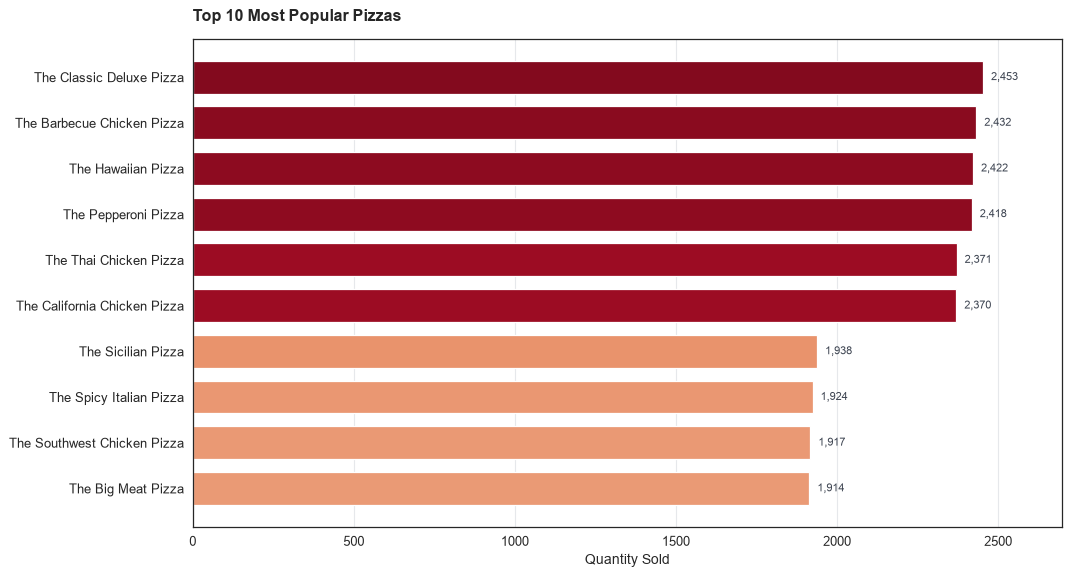

pizza_name
The Classic Deluxe Pizza        2453
The Barbecue Chicken Pizza      2432
The Hawaiian Pizza              2422
The Pepperoni Pizza             2418
The Thai Chicken Pizza          2371
The California Chicken Pizza    2370
The Sicilian Pizza              1938
The Spicy Italian Pizza         1924
The Southwest Chicken Pizza     1917
The Big Meat Pizza              1914


In [25]:
top_pizzas = (
    Sales_dataset.groupby("pizza_name")["quantity"].sum().sort_values(ascending=False)
)

t10 = top_pizzas.head(10).iloc[::-1]

plt.figure(figsize=(12, 6.5))
plt.barh(t10.index, t10.values, color=shade(t10.values), height=0.72)
plt.title("Top 10 Most Popular Pizzas", loc="left")
plt.xlabel("Quantity Sold")
for i, v in enumerate(t10.values):
    plt.text(v + 25, i, f"{v:,}", va="center", fontsize=9, color=SLATE)
plt.xlim(0, t10.max() * 1.10)
plt.gca().xaxis.grid(True)
plt.gca().yaxis.grid(False)
save_fig("01_top_10_pizzas.png")
plt.show()

print(top_pizzas.head(10).to_string())

### 6.2 Sales by pizza category

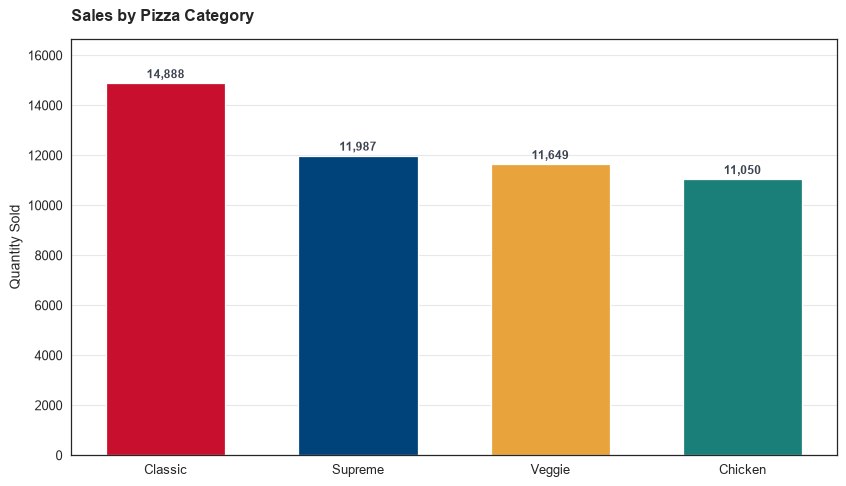

pizza_category
Classic    14888
Supreme    11987
Veggie     11649
Chicken    11050


In [26]:
category_sales = (
    Sales_dataset.groupby("pizza_category")["quantity"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(9.5, 5.5))
plt.bar(category_sales.index, category_sales.values,
        color=CATEGORICAL[:len(category_sales)], width=0.62)
plt.title("Sales by Pizza Category", loc="left")
plt.ylabel("Quantity Sold")
for i, v in enumerate(category_sales.values):
    plt.text(i, v + 200, f"{v:,}", ha="center", fontsize=9.5,
             fontweight="bold", color=SLATE)
plt.ylim(0, category_sales.max() * 1.12)
plt.gca().xaxis.grid(False)
save_fig("02_sales_by_category.png")
plt.show()

print(category_sales.to_string())

### 6.3 Sales by pizza size

Size matters for the purchase order, because ingredient grammage scales with it.

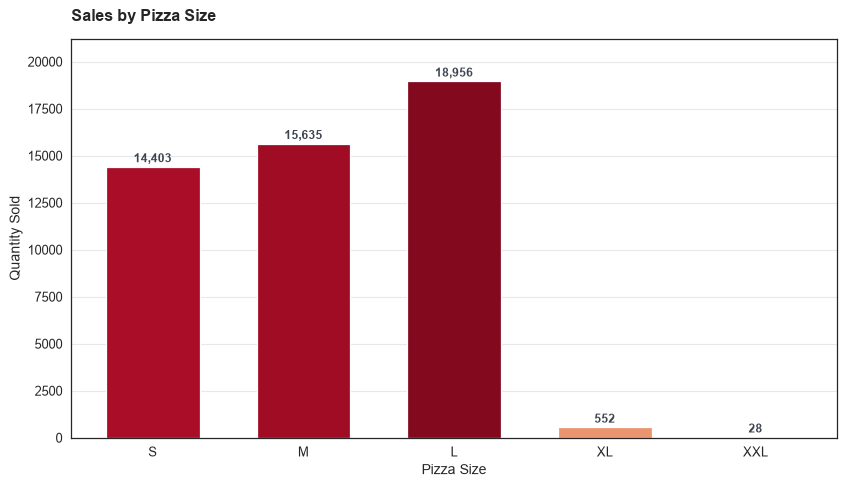

pizza_size
S      14403
M      15635
L      18956
XL       552
XXL       28


In [27]:
size_order = ["S", "M", "L", "XL", "XXL"]
size_sales = Sales_dataset.groupby("pizza_size")["quantity"].sum()
size_sales = size_sales.reindex([s for s in size_order if s in size_sales.index])

plt.figure(figsize=(9.5, 5.5))
plt.bar(size_sales.index, size_sales.values, color=shade(size_sales.values), width=0.62)
plt.title("Sales by Pizza Size", loc="left")
plt.xlabel("Pizza Size")
plt.ylabel("Quantity Sold")
for i, v in enumerate(size_sales.values):
    plt.text(i, v + 250, f"{v:,}", ha="center", fontsize=9.5,
             fontweight="bold", color=SLATE)
plt.ylim(0, size_sales.max() * 1.12)
plt.gca().xaxis.grid(False)
save_fig("03_sales_by_size.png")
plt.show()

print(size_sales.to_string())

### 6.4 Sales trend over time

Daily units sold across 2015 - this is the series the models have to learn.

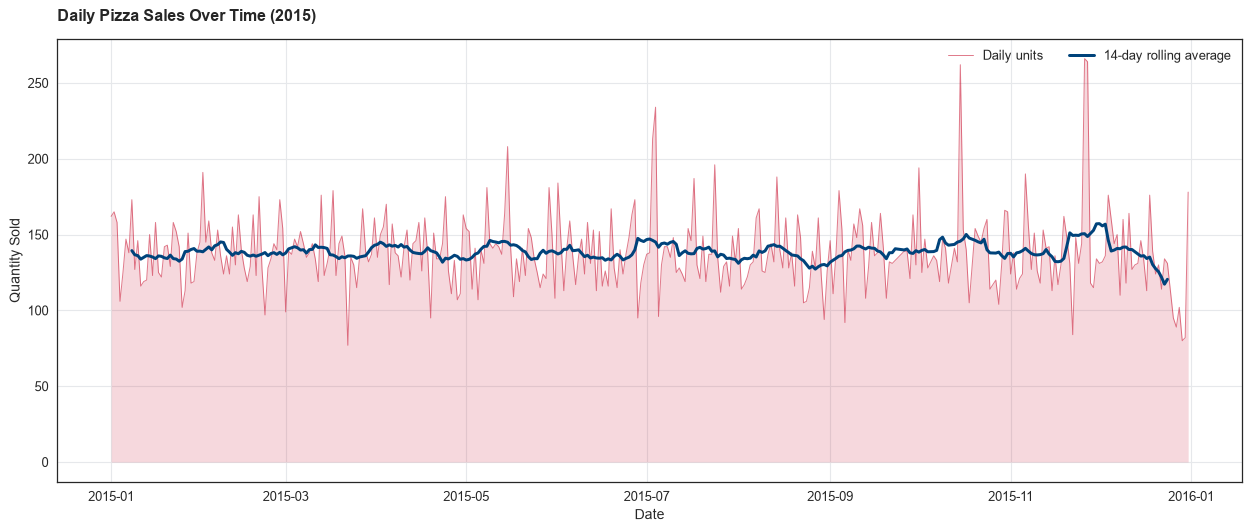

Mean daily units: 138.5
Min / Max daily : 77 / 266


In [28]:
daily_sales = Sales_dataset.groupby("order_date")["quantity"].sum().reset_index()

roll = daily_sales["quantity"].rolling(14, center=True).mean()

plt.figure(figsize=(14, 6))
plt.fill_between(daily_sales["order_date"], daily_sales["quantity"],
                 color=RED, alpha=0.16, linewidth=0)
plt.plot(daily_sales["order_date"], daily_sales["quantity"],
         color=RED, linewidth=0.8, alpha=0.55, label="Daily units")
plt.plot(daily_sales["order_date"], roll, color=NAVY, linewidth=2.4,
         label="14-day rolling average")
plt.title("Daily Pizza Sales Over Time (2015)", loc="left")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend(loc="upper right", ncol=2)
save_fig("04_daily_sales_trend.png")
plt.show()

print("Mean daily units:", round(daily_sales["quantity"].mean(), 1))
print("Min / Max daily :", daily_sales["quantity"].min(), "/", daily_sales["quantity"].max())

### 6.5 Sales by day of the week

Weekly seasonality is the strongest repeating pattern in the data.

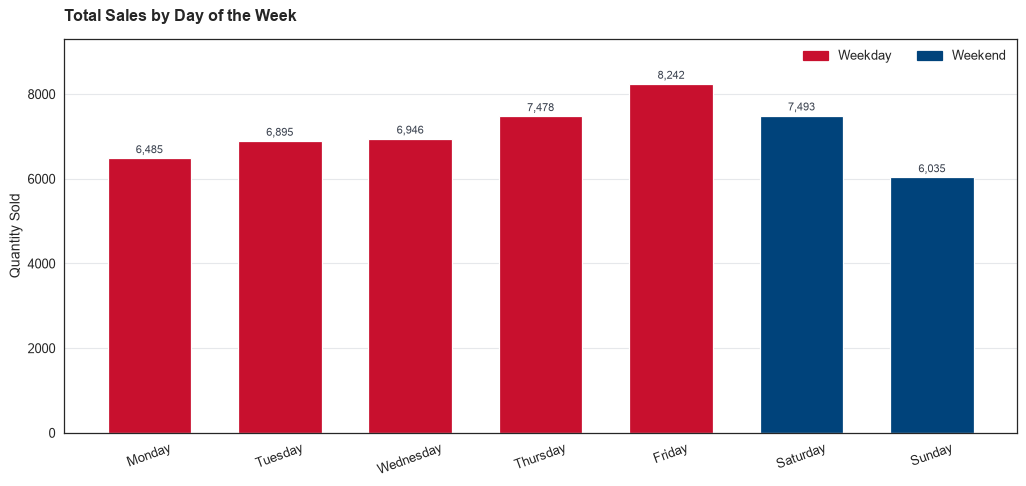

day_name
Monday       6485
Tuesday      6895
Wednesday    6946
Thursday     7478
Friday       8242
Saturday     7493
Sunday       6035


In [29]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day = Sales_dataset.groupby("day_name")["quantity"].sum().reindex(days_order)

is_weekend = [d in ("Saturday", "Sunday") for d in sales_by_day.index]
day_colors = [NAVY if w else RED for w in is_weekend]

plt.figure(figsize=(11.5, 5.5))
plt.bar(sales_by_day.index, sales_by_day.values, color=day_colors, width=0.64)
plt.title("Total Sales by Day of the Week", loc="left")
plt.ylabel("Quantity Sold")
for i, v in enumerate(sales_by_day.values):
    plt.text(i, v + 120, f"{v:,}", ha="center", fontsize=9, color=SLATE)
plt.ylim(0, sales_by_day.max() * 1.13)
plt.xticks(rotation=20)
plt.gca().xaxis.grid(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=RED),
           plt.Rectangle((0, 0), 1, 1, color=NAVY)]
plt.legend(handles, ["Weekday", "Weekend"], loc="upper right", ncol=2)
save_fig("05_sales_by_day_of_week.png")
plt.show()

print(sales_by_day.to_string())

### 6.6 Sales by month

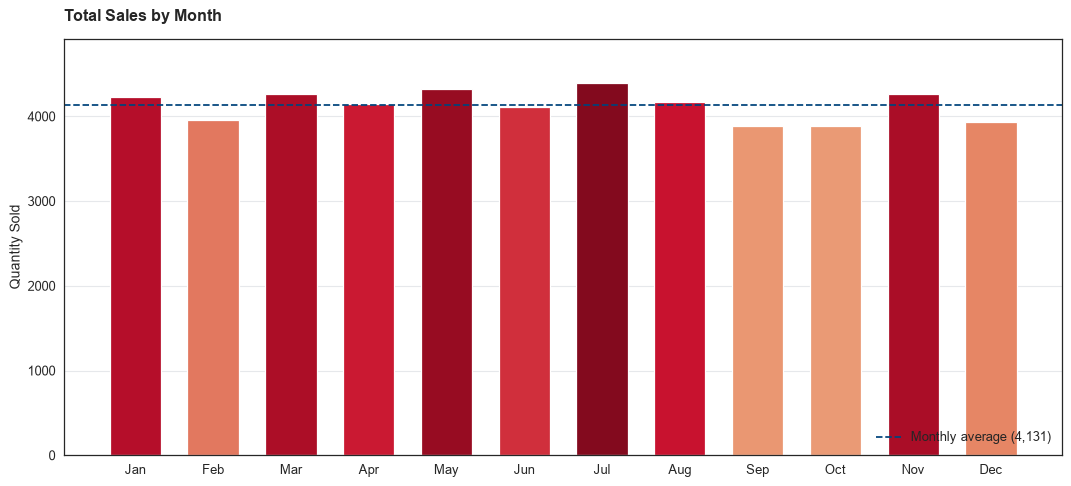

month
1     4232
2     3961
3     4261
4     4151
5     4328
6     4107
7     4392
8     4168
9     3890
10    3883
11    4266
12    3935


In [30]:
sales_by_month = Sales_dataset.groupby("month")["quantity"].sum()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 5.5))
plt.bar(month_labels, sales_by_month.values, color=shade(sales_by_month.values), width=0.66)
plt.axhline(sales_by_month.mean(), color=NAVY, linestyle="--", linewidth=1.4,
            label=f"Monthly average ({sales_by_month.mean():,.0f})")
plt.title("Total Sales by Month", loc="left")
plt.ylabel("Quantity Sold")
plt.ylim(0, sales_by_month.max() * 1.12)
plt.legend(loc="lower right")
plt.gca().xaxis.grid(False)
save_fig("06_sales_by_month.png")
plt.show()

print(sales_by_month.to_string())

### 6.7 Holiday and promotional effects

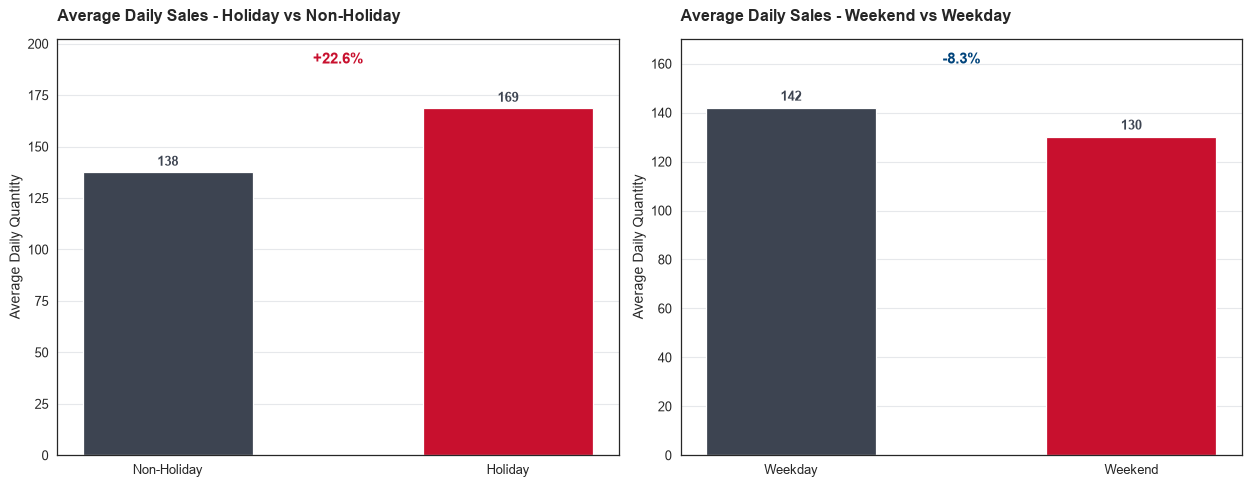

Avg daily units on holidays    : 168.8
Avg daily units on non-holidays: 137.7
Avg daily units on weekends    : 130.1
Avg daily units on weekdays    : 141.9


In [31]:
hol = Sales_dataset.groupby(["order_date", "holiday"])["quantity"].sum().reset_index()
promo = Sales_dataset.groupby(["order_date", "promotion"])["quantity"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, df, key, labels, title in [
    (axes[0], hol, "holiday", ["Non-Holiday", "Holiday"],
     "Holiday vs Non-Holiday"),
    (axes[1], promo, "promotion", ["Weekday", "Weekend"],
     "Weekend vs Weekday"),
]:
    means = df.groupby(key)["quantity"].mean()
    bars = ax.bar(labels, means.values, color=[SLATE, RED], width=0.5)
    ax.set_title(f"Average Daily Sales - {title}", loc="left")
    ax.set_ylabel("Average Daily Quantity")
    ax.set_ylim(0, means.max() * 1.20)
    ax.xaxis.grid(False)
    for b, v in zip(bars, means.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 3, f"{v:.0f}",
                ha="center", fontweight="bold", color=SLATE)
    delta = (means.iloc[1] - means.iloc[0]) / means.iloc[0] * 100
    ax.text(0.5, 0.94, f"{delta:+.1f}%", transform=ax.transAxes, ha="center",
            fontsize=12, fontweight="bold", color=RED if delta > 0 else NAVY)

save_fig("07_holiday_promotion_effect.png")
plt.show()

print("Avg daily units on holidays    :", round(hol[hol.holiday == 1]["quantity"].mean(), 1))
print("Avg daily units on non-holidays:", round(hol[hol.holiday == 0]["quantity"].mean(), 1))
print("Avg daily units on weekends    :", round(promo[promo.promotion == 1]["quantity"].mean(), 1))
print("Avg daily units on weekdays    :", round(promo[promo.promotion == 0]["quantity"].mean(), 1))

### 6.8 Correlation of sales metrics

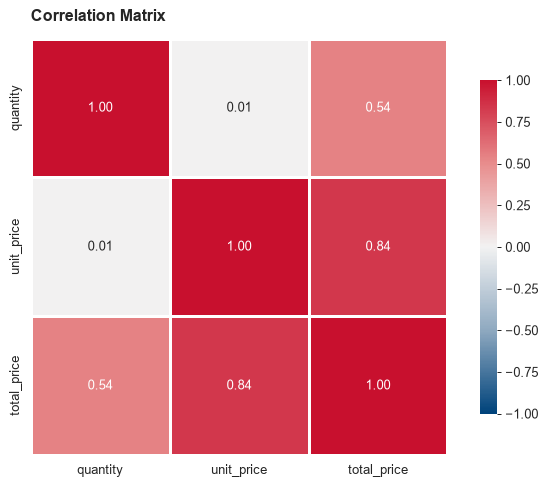

In [32]:
corr_matrix = Sales_dataset[["quantity", "unit_price", "total_price"]].corr()

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap=DIV, vmin=-1, vmax=1,
            linewidths=2, linecolor="white", fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix", loc="left")
plt.gca().grid(False)
save_fig("08_correlation_matrix.png")
plt.show()

### 6.9 Outlier check on order value

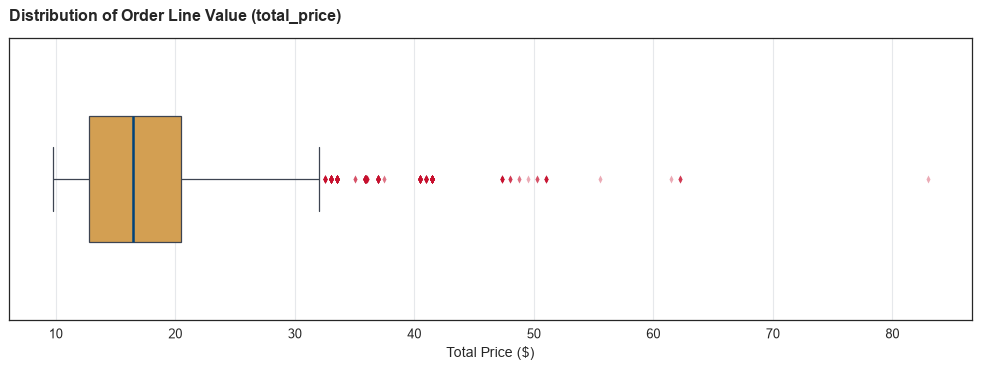

IQR upper fence: $32.12
Rows above fence: 613 (1.26%)

These are genuine large/multi-pizza orders, not data errors, so they are kept -
removing them would understate real ingredient demand.


In [33]:
plt.figure(figsize=(11, 4.2))
sns.boxplot(x=Sales_dataset["total_price"], color=AMBER, width=0.45,
            flierprops={"marker": "d", "markerfacecolor": RED,
                        "markeredgecolor": "none", "alpha": 0.35, "markersize": 4},
            medianprops={"color": NAVY, "linewidth": 2},
            boxprops={"edgecolor": SLATE}, whiskerprops={"color": SLATE},
            capprops={"color": SLATE})
plt.title("Distribution of Order Line Value (total_price)", loc="left")
plt.xlabel("Total Price ($)")
plt.gca().yaxis.grid(False)
save_fig("09_total_price_boxplot.png")
plt.show()

q1, q3 = Sales_dataset["total_price"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_out = int((Sales_dataset["total_price"] > upper).sum())
print(f"IQR upper fence: ${upper:.2f}")
print(f"Rows above fence: {n_out} ({n_out / len(Sales_dataset) * 100:.2f}%)")
print("\nThese are genuine large/multi-pizza orders, not data errors, so they are kept -")
print("removing them would understate real ingredient demand.")

## 7. Preparing the Series for Forecasting

### 7.1 Weekly aggregation

The purchase order covers **one week**, so the series is aggregated to weekly totals.
Weeks are labelled by their start date (Monday).

In [34]:
def prepare_weekly_sales(df):
    """Aggregate the daily sales into weekly totals, labelled by week start date."""
    weekly = (
        df.groupby(df["order_date"].dt.to_period("W").apply(lambda r: r.start_time))[
            "quantity"
        ]
        .sum()
    )
    weekly.index.name = "week"
    return weekly


pizza_sales_weekly = prepare_weekly_sales(Sales_dataset)

print("Weeks in series:", len(pizza_sales_weekly))
print(pizza_sales_weekly.head())
print("...")
print(pizza_sales_weekly.tail())

Weeks in series: 53
week
2014-12-29    591
2015-01-05    972
2015-01-12    917
2015-01-19    968
2015-01-26    975
Name: quantity, dtype: int64
...
week
2015-11-30    1013
2015-12-07     959
2015-12-14     962
2015-12-21     693
2015-12-28     442
Name: quantity, dtype: int64


#### Dropping the truncated weeks at each end

The data covers 1 Jan - 31 Dec 2015, and neither boundary lands on a week boundary. So the
first and last buckets are only **partially covered by the dataset** - each holds 4 days
instead of 7 - and both come out far below a normal week. Left in, they would teach every
model a slump at the start and a collapse at the end that never happened.

The right test is *date-range coverage*, not how many days recorded a sale. Some complete
weeks contain a day with genuinely zero sales (the store was shut on Christmas Day), and
that is real demand information which must be kept.

In [35]:
data_start = Sales_dataset["order_date"].min()
data_end = Sales_dataset["order_date"].max()

coverage = pd.DataFrame({
    "week_start": pizza_sales_weekly.index,
    "units": pizza_sales_weekly.values,
})
coverage["week_end"] = coverage["week_start"] + pd.Timedelta(days=6)
coverage["days_in_range"] = coverage.apply(
    lambda r: len(pd.date_range(max(r["week_start"], data_start),
                                min(r["week_end"], data_end), freq="D")),
    axis=1,
)
coverage["complete"] = coverage["days_in_range"] == 7

print(f"Data covers {data_start.date()} -> {data_end.date()}\n")
print("Boundary buckets:")
print(coverage.head(2).to_string(index=False))
print("...")
print(coverage.tail(2).to_string(index=False))

dropped = coverage[~coverage["complete"]]
print(f"\nDropping {len(dropped)} truncated week(s):")
for _, r in dropped.iterrows():
    print(f"  {r['week_start'].date()}  {r['units']:>4} units  "
          f"({r['days_in_range']}/7 days in range)")

pizza_sales_weekly = pizza_sales_weekly[coverage["complete"].values]

print(f"\nWeeks used for modelling: {len(pizza_sales_weekly)}")
print("Range:", pizza_sales_weekly.index.min().date(), "->", pizza_sales_weekly.index.max().date())
print(f"Mean weekly units: {pizza_sales_weekly.mean():.0f}")

Data covers 2015-01-01 -> 2015-12-31

Boundary buckets:
week_start  units   week_end  days_in_range  complete
2014-12-29    591 2015-01-04              4     False
2015-01-05    972 2015-01-11              7      True
...
week_start  units   week_end  days_in_range  complete
2015-12-21    693 2015-12-27              7      True
2015-12-28    442 2016-01-03              4     False

Dropping 2 truncated week(s):
  2014-12-29   591 units  (4/7 days in range)
  2015-12-28   442 units  (4/7 days in range)

Weeks used for modelling: 51
Range: 2015-01-05 -> 2015-12-21
Mean weekly units: 952


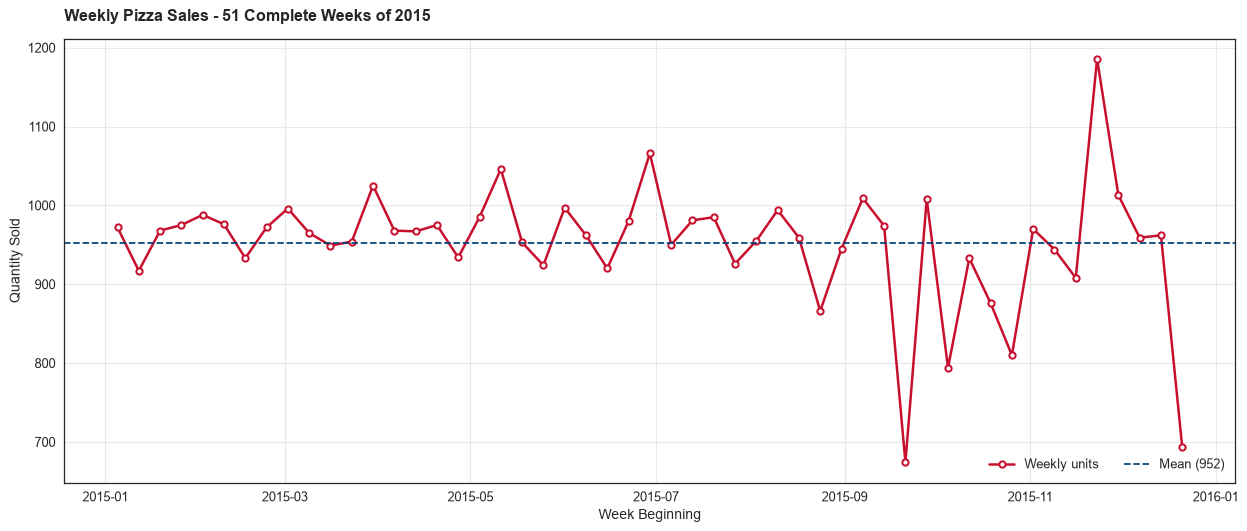

In [36]:
plt.figure(figsize=(14, 6))
plt.plot(pizza_sales_weekly.index, pizza_sales_weekly.values,
         color=RED, linewidth=2, marker="o", markersize=5,
         markerfacecolor="white", markeredgewidth=1.6, label="Weekly units")
plt.axhline(pizza_sales_weekly.mean(), color=NAVY, linestyle="--", linewidth=1.4,
            label=f"Mean ({pizza_sales_weekly.mean():,.0f})")
plt.title("Weekly Pizza Sales - 51 Complete Weeks of 2015", loc="left")
plt.xlabel("Week Beginning")
plt.ylabel("Quantity Sold")
plt.legend(loc="lower right", ncol=2)
save_fig("10_weekly_sales.png")
plt.show()

### 7.2 Stationarity test (ADF)

ARIMA needs a stationary series. The Augmented Dickey-Fuller test checks whether
differencing is required.

- **H0**: the series is *not* stationary
- **H1**: the series is stationary

In [37]:
def adf_test(series, label=""):
    result = adfuller(series)
    print(f"--- ADF test {label} ---")
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    if result[1] <= 0.05:
        print("=> Reject H0: the series IS stationary.\n")
    else:
        print("=> Cannot reject H0: the series is NOT stationary.\n")
    return result[1]


p_level = adf_test(pizza_sales_weekly, "(levels)")
p_diff = adf_test(pizza_sales_weekly.diff().dropna(), "(first difference)")

--- ADF test (levels) ---
ADF statistic : -6.3402
p-value       : 0.0000
Lags used     : 0
Observations  : 50
=> Reject H0: the series IS stationary.

--- ADF test (first difference) ---
ADF statistic : -3.7995
p-value       : 0.0029
Lags used     : 11
Observations  : 38
=> Reject H0: the series IS stationary.



### 7.3 ACF and PACF

These guide the choice of the AR (`p`) and MA (`q`) terms.

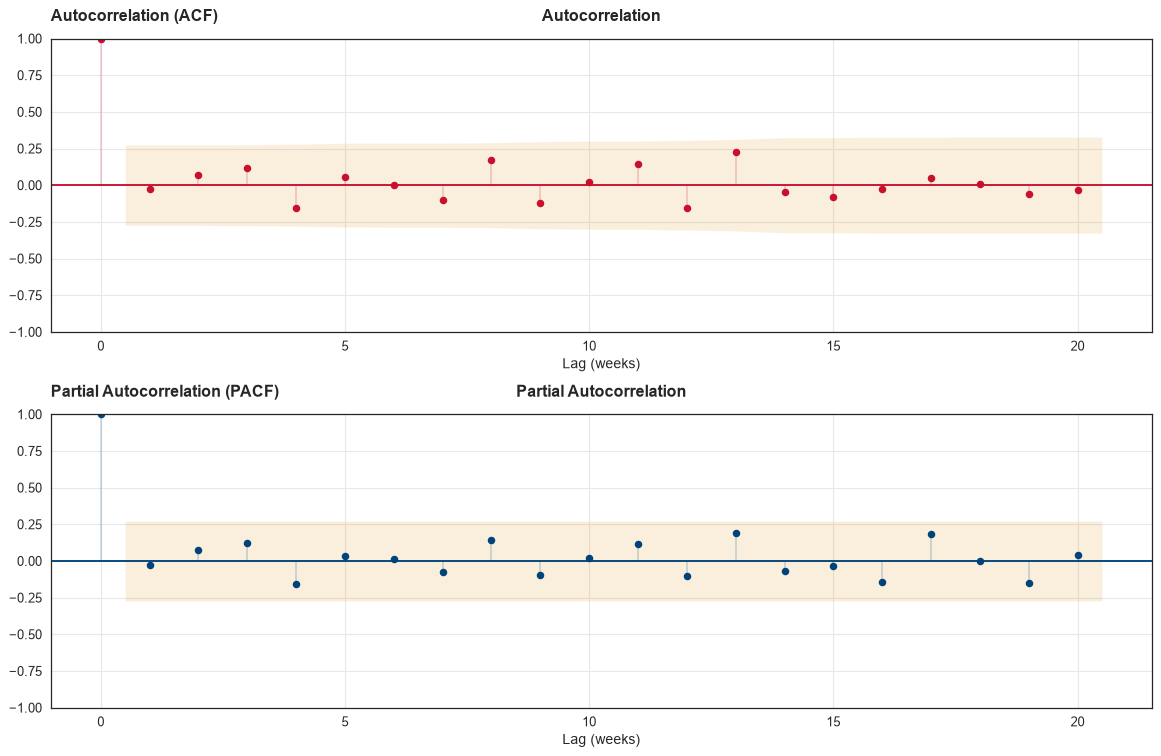

In [38]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8.5))

for ax, fn, name, col in [(ax1, plot_acf, "Autocorrelation (ACF)", RED),
                          (ax2, plot_pacf, "Partial Autocorrelation (PACF)", NAVY)]:
    kw = {"method": "ywm"} if fn is plot_pacf else {}
    fn(pizza_sales_weekly, lags=20, ax=ax, color=col,
       vlines_kwargs={"colors": col}, **kw)
    ax.set_title(name, loc="left")
    ax.set_xlabel("Lag (weeks)")
    for coll in ax.collections:       # the confidence band
        coll.set_facecolor(AMBER)
        coll.set_alpha(0.18)

save_fig("11_acf_pacf.png")
plt.show()

### 7.4 Train / test split

The last 20% of weeks are held out. Because this is a time series, the split is
**chronological** - never shuffled - so the model is always predicting forward in time.

In [39]:
train_size = int(0.8 * len(pizza_sales_weekly))
train = pizza_sales_weekly[:train_size]
test = pizza_sales_weekly[train_size:]

print(f"Train: {len(train)} weeks  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} weeks  ({test.index.min().date()} -> {test.index.max().date()})")


def mape(actual, predicted):
    """Mean Absolute Percentage Error - the project's evaluation metric."""
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    return np.mean(np.abs((actual - predicted) / actual))


model_scores = {}


def plot_forecast(index, actual, predicted, title, filename):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(13, 7.5), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12},
    )

    ax.fill_between(index, actual, predicted, color=AMBER, alpha=0.22,
                    label="Gap", linewidth=0)
    ax.plot(index, actual, color=NAVY, linewidth=2.4, marker="o", markersize=6,
            markerfacecolor="white", markeredgewidth=1.6, label="Actual")
    ax.plot(index, predicted, color=RED, linewidth=2.2, linestyle="--",
            marker="D", markersize=5, label="Predicted")
    ax.set_title(title, loc="left")
    ax.set_ylabel("Weekly Quantity Sold")
    ax.legend(loc="best", ncol=3)

    err = (predicted - actual) / actual * 100
    axr.bar(index, err, color=[RED if e > 0 else NAVY for e in err], width=4.5)
    axr.axhline(0, color=SLATE, linewidth=1)
    axr.set_ylabel("Error %")
    axr.set_xlabel("Week Beginning")
    axr.xaxis.grid(False)
    plt.setp(axr.get_xticklabels(), rotation=45, ha="right")

    save_fig(filename)
    plt.show()

Train: 40 weeks  (2015-01-05 -> 2015-10-05)
Test : 11 weeks  (2015-10-12 -> 2015-12-21)


## 8. Sales Prediction - Model Building

Five forecasting approaches are trained on the same weekly series and scored with the
same metric (MAPE) on the same held-out weeks, so the comparison is fair.

| Model | Why it is a candidate |
|---|---|
| ARIMA | Captures trend and autocorrelation in non-seasonal data |
| SARIMA | Extends ARIMA with an explicit seasonal component |
| Prophet | Handles trend changepoints and holiday effects |
| Regression | Simple, fully interpretable calendar-feature baseline |
| LSTM | Neural network able to learn non-linear temporal patterns |

### 8.1 ARIMA

`p` (autoregressive), `d` (differencing) and `q` (moving average) are selected by grid
search, keeping the combination with the lowest MAPE on the held-out weeks.

In [40]:
def tune_arima_model(train, test, p_values, d_values, q_values):
    best_score, best_params, best_predictions = float("inf"), None, None
    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            model = ARIMA(train, order=(p, d, q)).fit()
            predictions = model.forecast(steps=len(test))
            score = mape(test, predictions)
            if np.isfinite(score) and score < best_score:
                best_score, best_params, best_predictions = score, (p, d, q), predictions
        except Exception:
            continue
    return best_predictions, best_score, best_params


arima_predictions, arima_mape_score, arima_best_params = tune_arima_model(
    train, test, range(0, 6), range(0, 2), range(0, 6)
)

model_scores["ARIMA"] = arima_mape_score
print(f"Best ARIMA order : {arima_best_params}")
print(f"Best ARIMA MAPE  : {arima_mape_score:.4f}")

arima_predictions = pd.Series(np.asarray(arima_predictions), index=test.index)
print("\nActual vs Predicted:")
print(pd.DataFrame({"Actual": test, "Predicted": arima_predictions.round(1)}).to_string())

Best ARIMA order : (0, 0, 3)
Best ARIMA MAPE  : 0.0853

Actual vs Predicted:
            Actual  Predicted
week                         
2015-10-12     933      927.9
2015-10-19     876      938.1
2015-10-26     810      924.3
2015-11-02     970      955.1
2015-11-09     944      955.1
2015-11-16     908      955.1
2015-11-23    1186      955.1
2015-11-30    1013      955.1
2015-12-07     959      955.1
2015-12-14     962      955.1
2015-12-21     693      955.1


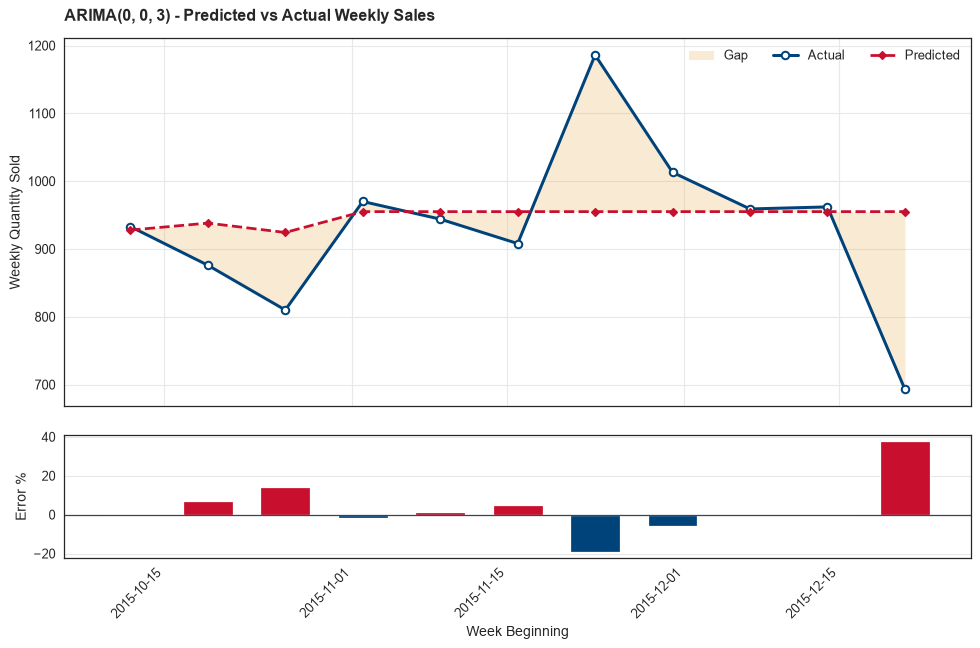

In [41]:
plot_forecast(test.index, test.values, arima_predictions.values,
              f"ARIMA{arima_best_params} - Predicted vs Actual Weekly Sales",
              "12_arima_forecast.png")

### 8.2 SARIMA (Seasonal ARIMA)

SARIMA adds a seasonal `(P, D, Q, s)` block on top of ARIMA. A compact grid is searched,
including the `s = 7` configuration used as the baseline in the reference approach.

In [42]:
def tune_sarima_model(train, test, candidates):
    best_score, best_params, best_predictions = float("inf"), None, None
    for order, seasonal_order in candidates:
        try:
            model = SARIMAX(
                train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)
            predictions = model.forecast(steps=len(test))
            score = mape(test, predictions)
            if np.isfinite(score) and score < best_score:
                best_score = score
                best_params = (order, seasonal_order)
                best_predictions = predictions
        except Exception:
            continue
    return best_predictions, best_score, best_params


sarima_candidates = [
    (o, s)
    for o in itertools.product(range(0, 3), range(0, 2), range(0, 3))
    for s in [(1, 1, 1, 7), (1, 0, 1, 7), (0, 1, 1, 7), (1, 1, 0, 7),
              (1, 1, 1, 4), (1, 0, 1, 4), (1, 1, 1, 13)]
]

sarima_predictions, sarima_mape_score, sarima_best_params = tune_sarima_model(
    train, test, sarima_candidates
)

model_scores["SARIMA"] = sarima_mape_score
print(f"Best SARIMA order        : {sarima_best_params[0]}")
print(f"Best SARIMA seasonal     : {sarima_best_params[1]}")
print(f"Best SARIMA MAPE         : {sarima_mape_score:.4f}")

sarima_predictions = pd.Series(np.asarray(sarima_predictions), index=test.index)
print("\nActual vs Predicted:")
print(pd.DataFrame({"Actual": test, "Predicted": sarima_predictions.round(1)}).to_string())

Best SARIMA order        : (1, 0, 2)
Best SARIMA seasonal     : (1, 1, 1, 13)
Best SARIMA MAPE         : 0.0804

Actual vs Predicted:
            Actual  Predicted
week                         
2015-10-12     933      942.9
2015-10-19     876      937.3
2015-10-26     810      917.5
2015-11-02     970      957.5
2015-11-09     944      994.6
2015-11-16     908      933.0
2015-11-23    1186      903.4
2015-11-30    1013      964.2
2015-12-07     959      962.8
2015-12-14     962      929.8
2015-12-21     693      868.5


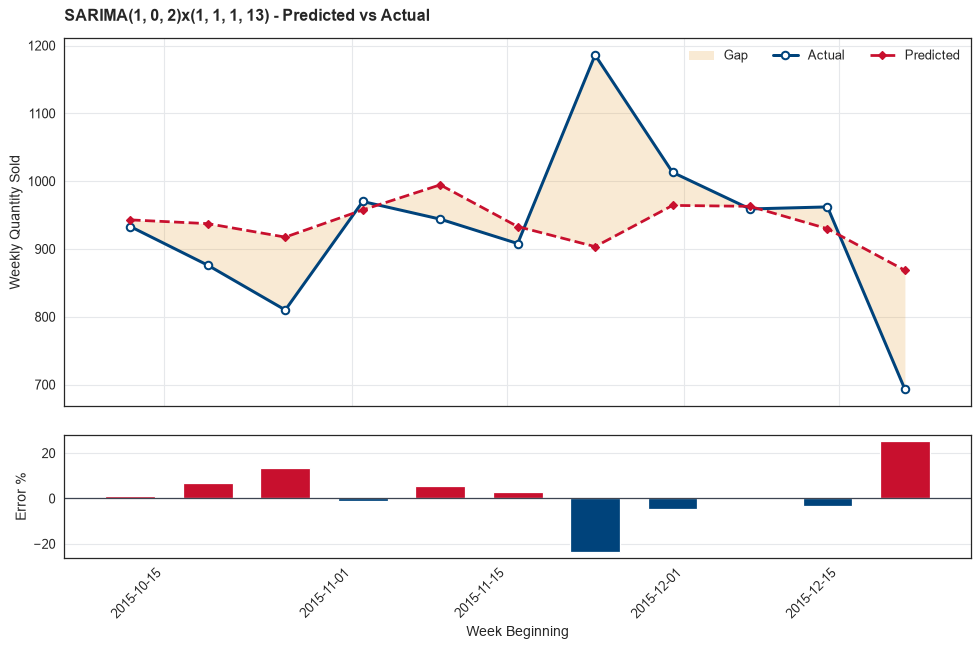

In [43]:
plot_forecast(test.index, test.values, sarima_predictions.values,
              f"SARIMA{sarima_best_params[0]}x{sarima_best_params[1]} - Predicted vs Actual",
              "13_sarima_forecast.png")

### 8.3 Prophet

Prophet decomposes the series into trend, seasonality and holiday effects. US holidays
are added explicitly, since the EDA showed holidays behave differently.

In [44]:
prophet_train = pd.DataFrame({"ds": train.index, "y": train.values})
prophet_test = pd.DataFrame({"ds": test.index, "y": test.values})

prophet_model = Prophet(weekly_seasonality=False, daily_seasonality=False)
prophet_model.add_country_holidays(country_name="US")
prophet_model.fit(prophet_train)

prophet_future = prophet_model.make_future_dataframe(periods=len(test), freq="W-MON")
prophet_forecast = prophet_model.predict(prophet_future)
prophet_predictions = prophet_forecast["yhat"].values[-len(test):]

prophet_mape_score = mape(test.values, prophet_predictions)
model_scores["Prophet"] = prophet_mape_score
print(f"Prophet MAPE: {prophet_mape_score:.4f}")

prophet_predictions = pd.Series(prophet_predictions, index=test.index)
print("\nActual vs Predicted:")
print(pd.DataFrame({"Actual": test, "Predicted": prophet_predictions.round(1)}).to_string())

14:52:26 - cmdstanpy - INFO - Chain [1] start processing


14:52:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE: 0.0962

Actual vs Predicted:
            Actual  Predicted
week                         
2015-10-12     933      916.3
2015-10-19     876      914.2
2015-10-26     810      912.1
2015-11-02     970      910.1
2015-11-09     944      908.0
2015-11-16     908      905.9
2015-11-23    1186      903.9
2015-11-30    1013      901.8
2015-12-07     959      899.7
2015-12-14     962      897.7
2015-12-21     693      895.6


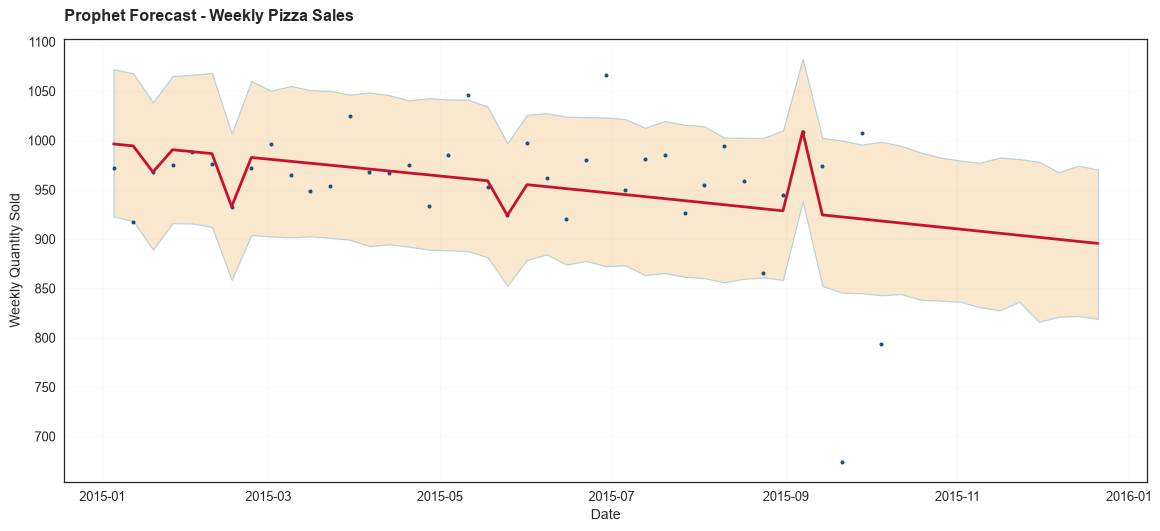

In [45]:
fig = prophet_model.plot(prophet_forecast, figsize=(13, 6))
ax = fig.gca()

# Recolour Prophet's default blue/black styling into the project palette
for line in ax.get_lines():
    if line.get_marker() in (".", "o"):       # observed points
        line.set(color=NAVY, markersize=4.5, alpha=0.85)
    else:                                      # trend line
        line.set(color=RED, linewidth=2.2)
for coll in ax.collections:                    # uncertainty interval
    coll.set(facecolor=AMBER, alpha=0.25)

ax.set_title("Prophet Forecast - Weekly Pizza Sales", loc="left",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Weekly Quantity Sold")
ax.grid(True, color="#E6E8EB", linewidth=0.9)
save_fig("14_prophet_components.png")
plt.show()

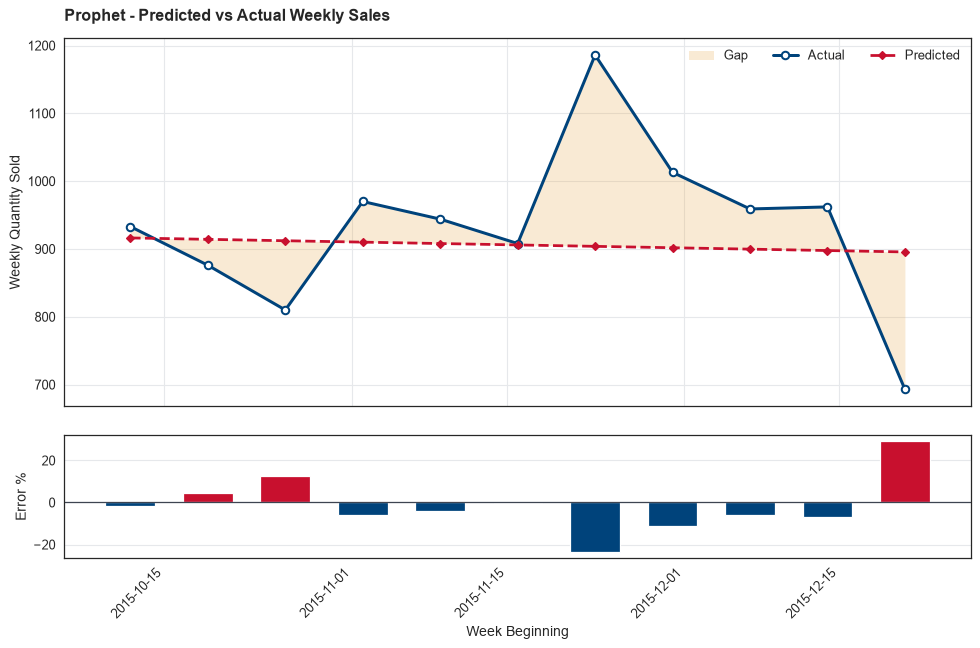

In [46]:
plot_forecast(test.index, test.values, prophet_predictions.values,
              "Prophet - Predicted vs Actual Weekly Sales",
              "15_prophet_forecast.png")

### 8.4 Regression Model

A linear regression on calendar features - the interpretable baseline that any
time-series model has to beat to justify its complexity.

In [47]:
reg_df = pizza_sales_weekly.reset_index()
reg_df.columns = ["week", "quantity"]
reg_df["week_of_year"] = reg_df["week"].dt.isocalendar().week.astype(int)
reg_df["month"] = reg_df["week"].dt.month
reg_df["quarter"] = reg_df["week"].dt.quarter
reg_df["time_index"] = np.arange(len(reg_df))

features = ["week_of_year", "month", "quarter", "time_index"]

reg_train, reg_test = reg_df[:train_size], reg_df[train_size:]
X_train, y_train = reg_train[features], reg_train["quantity"]
X_test, y_test = reg_test[features], reg_test["quantity"]

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)
regression_predictions = regression_model.predict(X_test)

regression_mape_score = mape(y_test.values, regression_predictions)
model_scores["Regression"] = regression_mape_score
print(f"Regression MAPE: {regression_mape_score:.4f}")

print("\nCoefficients:")
for f, c in zip(features, regression_model.coef_):
    print(f"  {f:14s} {c:+.2f}")

regression_predictions = pd.Series(regression_predictions, index=test.index)
print("\nActual vs Predicted:")
print(pd.DataFrame({"Actual": test, "Predicted": regression_predictions.round(1)}).to_string())

Regression MAPE: 0.0914

Coefficients:
  week_of_year   -1.61
  month          +19.36
  quarter        -38.57
  time_index     -1.61

Actual vs Predicted:
            Actual  Predicted
week                         
2015-10-12     933      909.3
2015-10-19     876      906.1
2015-10-26     810      902.9
2015-11-02     970      919.0
2015-11-09     944      915.8
2015-11-16     908      912.6
2015-11-23    1186      909.4
2015-11-30    1013      906.1
2015-12-07     959      922.3
2015-12-14     962      919.1
2015-12-21     693      915.8


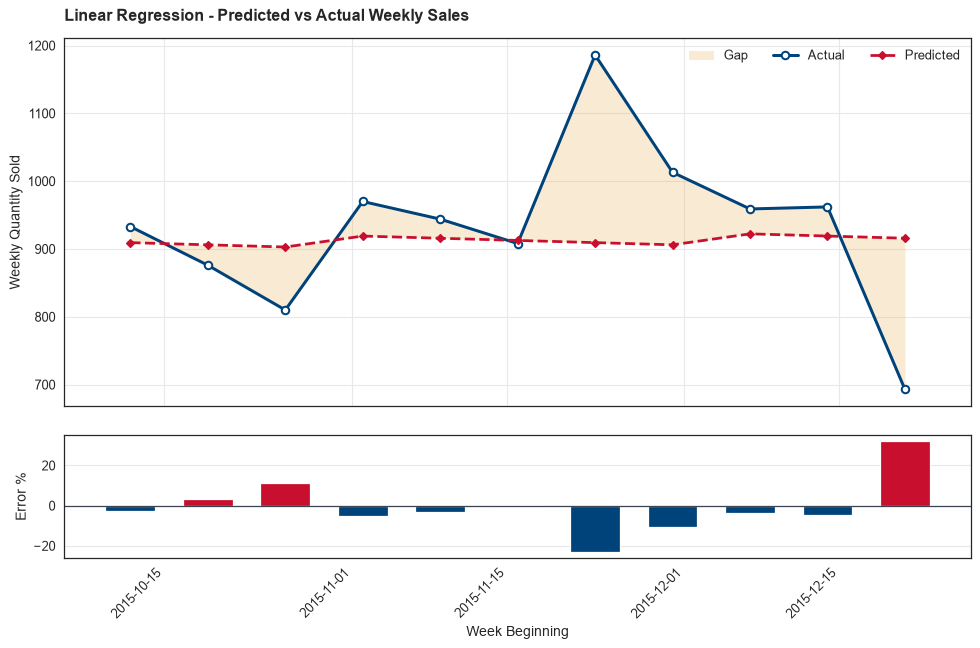

In [48]:
plot_forecast(test.index, test.values, regression_predictions.values,
              "Linear Regression - Predicted vs Actual Weekly Sales",
              "16_regression_forecast.png")

### 8.5 LSTM

A recurrent neural network trained on scaled sequences of the previous 3 weeks.
The scaler is fitted on the training data only, so no future information leaks backwards.

In [49]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))


def create_lstm_dataset(data, time_steps=1):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)


time_steps = 3

# Prefix the test window with the tail of train so that every held-out week gets a
# prediction, without the model ever seeing a test value as an input target.
combined = np.concatenate([train_scaled[-time_steps:], test_scaled])

X_train_l, y_train_l = create_lstm_dataset(train_scaled, time_steps)
X_test_l, y_test_l = create_lstm_dataset(combined, time_steps)

X_train_l = X_train_l.reshape((X_train_l.shape[0], X_train_l.shape[1], 1))
X_test_l = X_test_l.reshape((X_test_l.shape[0], X_test_l.shape[1], 1))

print("LSTM train sequences:", X_train_l.shape)
print("LSTM test sequences :", X_test_l.shape)

import tensorflow as tf
tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(time_steps, 1)),
    LSTM(50, activation="relu"),
    Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")
history = lstm_model.fit(X_train_l, y_train_l, epochs=200, batch_size=8, verbose=0)

lstm_scaled_preds = lstm_model.predict(X_test_l, verbose=0)
lstm_predictions = scaler.inverse_transform(lstm_scaled_preds).flatten()

lstm_mape_score = mape(test.values, lstm_predictions)
model_scores["LSTM"] = lstm_mape_score
print(f"\nLSTM MAPE: {lstm_mape_score:.4f}")
print(f"Final training loss: {history.history['loss'][-1]:.5f}")

lstm_predictions = pd.Series(lstm_predictions, index=test.index)
print("\nActual vs Predicted:")
print(pd.DataFrame({"Actual": test, "Predicted": lstm_predictions.round(1)}).to_string())

LSTM train sequences: (37, 3, 1)
LSTM test sequences : (11, 3, 1)



LSTM MAPE: 0.0984
Final training loss: 0.02510

Actual vs Predicted:
            Actual    Predicted
week                           
2015-10-12     933   863.700012
2015-10-19     876   916.200012
2015-10-26     810   912.700012
2015-11-02     970   939.299988
2015-11-09     944   897.200012
2015-11-16     908   921.099976
2015-11-23    1186   957.599976
2015-11-30    1013   963.599976
2015-12-07     959   981.900024
2015-12-14     962  1034.900024
2015-12-21     693   969.599976


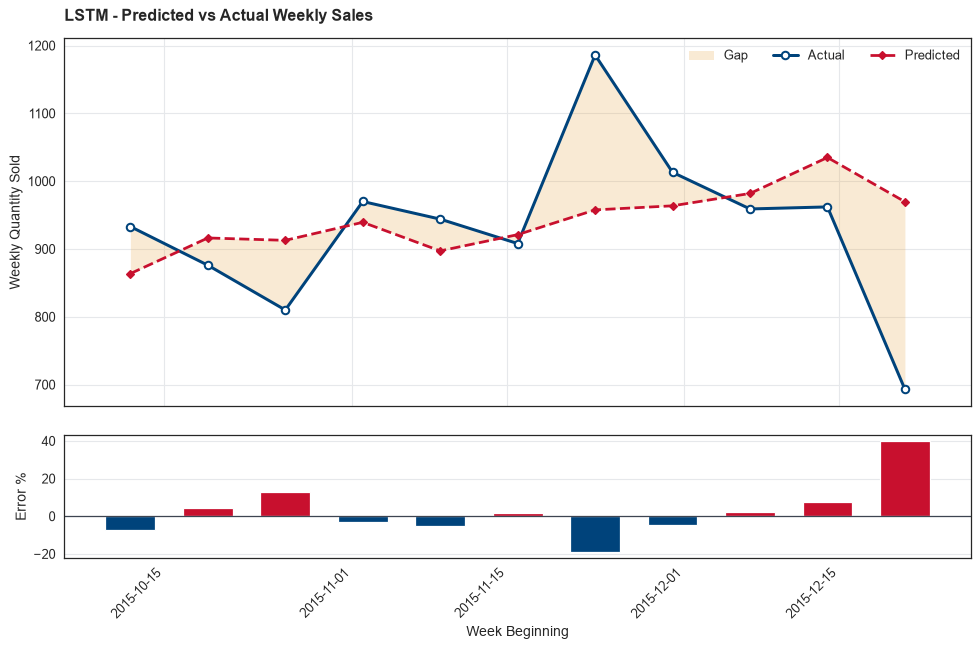

In [50]:
plot_forecast(test.index, test.values, lstm_predictions.values,
              "LSTM - Predicted vs Actual Weekly Sales",
              "17_lstm_forecast.png")

## 9. Model Evaluation and Comparison

All five models scored on the same held-out weeks with MAPE. Lower is better.

In [51]:
df_performance = (
    pd.DataFrame({"Model": list(model_scores.keys()), "MAPE": list(model_scores.values())})
    .sort_values("MAPE")
    .reset_index(drop=True)
)
df_performance["Rank"] = df_performance.index + 1
df_performance["Accuracy (1-MAPE)"] = (1 - df_performance["MAPE"]).map(lambda v: f"{v:.2%}")
df_performance["Best/Worst"] = ""
df_performance.loc[0, "Best/Worst"] = "Best"
df_performance.loc[len(df_performance) - 1, "Best/Worst"] = "Worst"

df_performance.to_csv(os.path.join(OUTPUTS, "model_comparison.csv"), index=False)
df_performance

,Model,MAPE,Rank,Accuracy (1-MAPE),Best/Worst
0,SARIMA,0.080394,1,91.96%,Best
1,ARIMA,0.085265,2,91.47%,
2,Regression,0.091375,3,90.86%,
3,Prophet,0.096227,4,90.38%,
4,LSTM,0.098433,5,90.16%,Worst


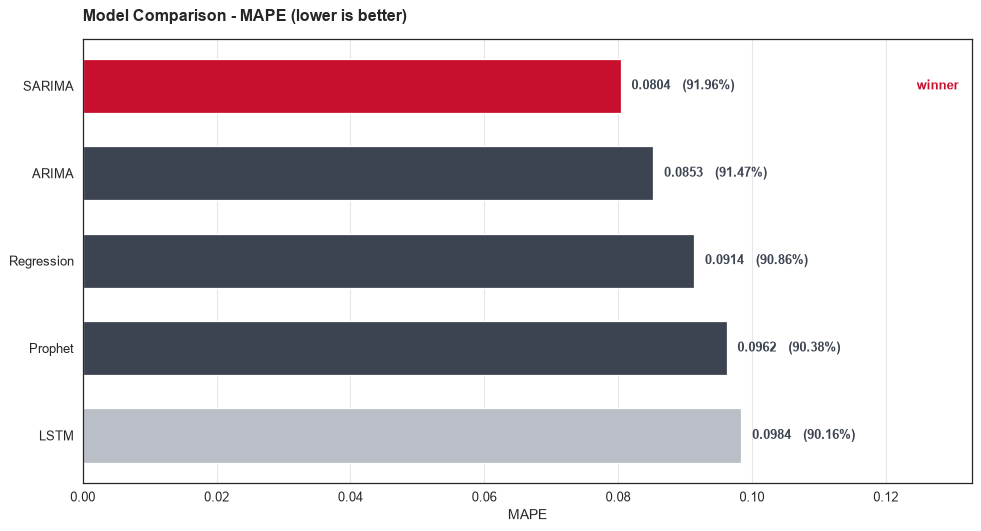

In [52]:
order = df_performance.iloc[::-1]          # worst at top, best at bottom
bar_colors = [SLATE] * len(order)
bar_colors[-1] = RED                        # winner
bar_colors[0] = "#B9BEC7"                   # weakest

plt.figure(figsize=(11, 6))
bars = plt.barh(order["Model"], order["MAPE"], color=bar_colors, height=0.62)
plt.title("Model Comparison - MAPE (lower is better)", loc="left")
plt.xlabel("MAPE")
for bar, v, acc in zip(bars, order["MAPE"], order["Accuracy (1-MAPE)"]):
    plt.text(v + 0.0016, bar.get_y() + bar.get_height() / 2,
             f"{v:.4f}   ({acc})", va="center", fontsize=10,
             fontweight="bold", color=SLATE)
plt.xlim(0, df_performance["MAPE"].max() * 1.35)
ax = plt.gca()
ax.yaxis.grid(False)
# Label the winning bar itself - the best model is the last row of `order`
ax.text(ax.get_xlim()[1] * 0.985, len(order) - 1, "winner",
        ha="right", va="center", color=RED, fontweight="bold", fontsize=10.5)
save_fig("18_model_comparison.png")
plt.show()

In [53]:
best_model_name = df_performance.loc[0, "Model"]
best_model_mape = df_performance.loc[0, "MAPE"]

print(f"Best model: {best_model_name}  (MAPE {best_model_mape:.4f}"
      f" = {1 - best_model_mape:.2%} accuracy)")

Best model: SARIMA  (MAPE 0.0804 = 91.96% accuracy)


### All models on one chart

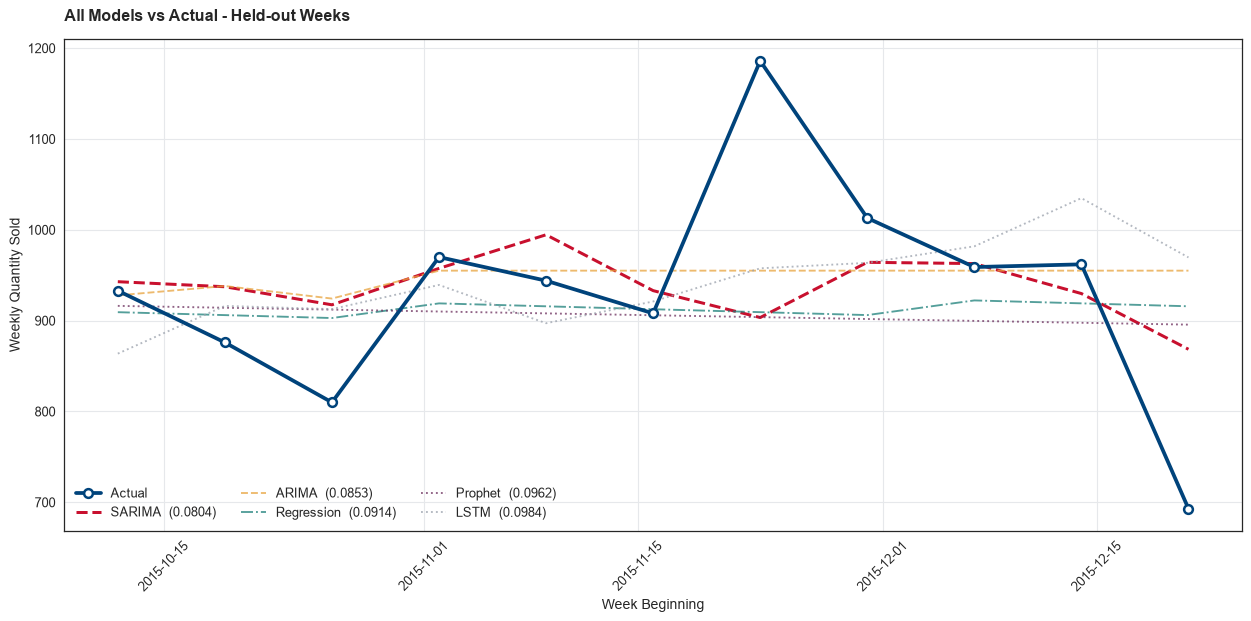

In [54]:
series = [
    ("SARIMA", sarima_predictions, RED, "--"),
    ("ARIMA", arima_predictions, AMBER, "--"),
    ("Regression", regression_predictions, TEAL, "-."),
    ("Prophet", prophet_predictions, PLUM, ":"),
    ("LSTM", lstm_predictions, "#9AA1AC", ":"),
]

plt.figure(figsize=(14, 7))
plt.plot(test.index, test.values, label="Actual", color=NAVY, marker="o",
         markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=3, zorder=5)
for name, preds, col, style in series:
    lw = 2.4 if name == best_model_name else 1.5
    al = 1.0 if name == best_model_name else 0.75
    plt.plot(test.index, preds.values, style, color=col, linewidth=lw, alpha=al,
             label=f"{name}  ({model_scores[name]:.4f})")
plt.title("All Models vs Actual - Held-out Weeks", loc="left")
plt.xlabel("Week Beginning")
plt.ylabel("Weekly Quantity Sold")
plt.xticks(rotation=45)
plt.legend(ncol=3, loc="lower left")
save_fig("19_all_models_comparison.png")
plt.show()

## 10. Saving the Best Model

The winning model is refitted on the **complete** weekly series - the train/test split has
done its job of picking the model, so the deployed version should learn from every week
available - and persisted with pickle.

In [55]:
def fit_best_model(series):
    """Fit the winning model family on a full series and return the fitted object."""
    if best_model_name == "SARIMA":
        return SARIMAX(
            series, order=sarima_best_params[0], seasonal_order=sarima_best_params[1],
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
    if best_model_name == "ARIMA":
        return ARIMA(series, order=arima_best_params).fit()
    raise ValueError(f"No refit path defined for {best_model_name}")


if best_model_name in ("SARIMA", "ARIMA"):
    final_model = fit_best_model(pizza_sales_weekly)
    print(final_model.summary())
else:
    final_model = None
    print(f"Best model is {best_model_name}; it is refitted per pizza type in the next step.")

                                      SARIMAX Results                                       
Dep. Variable:                             quantity   No. Observations:                   51
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 13)   Log Likelihood                -133.861
Date:                              Wed, 09 Sep 2026   AIC                            279.722
Time:                                      14:52:39   BIC                            286.268
Sample:                                  01-05-2015   HQIC                           281.264
                                       - 12-21-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4352      2.234      0.195      0.846      -3.943       4.813
ma.L1         -0.37

In [56]:
model_path = os.path.join(MODELS, "best_sales_model.pkl")

with open(model_path, "wb") as f:
    pickle.dump(
        {
            "model_name": best_model_name,
            "mape": float(best_model_mape),
            "arima_order": arima_best_params,
            "sarima_order": sarima_best_params,
            "fitted_total_series_model": final_model,
            "train_end": str(pizza_sales_weekly.index.max().date()),
        },
        f,
    )

print(f"Model saved to {model_path}")

# Verify it loads back
with open(model_path, "rb") as f:
    loaded = pickle.load(f)
print(f"Reloaded OK -> {loaded['model_name']} (MAPE {loaded['mape']:.4f})")

Model saved to ..\models\best_sales_model.pkl
Reloaded OK -> SARIMA (MAPE 0.0804)


### Forecasting total sales for the next 7 days

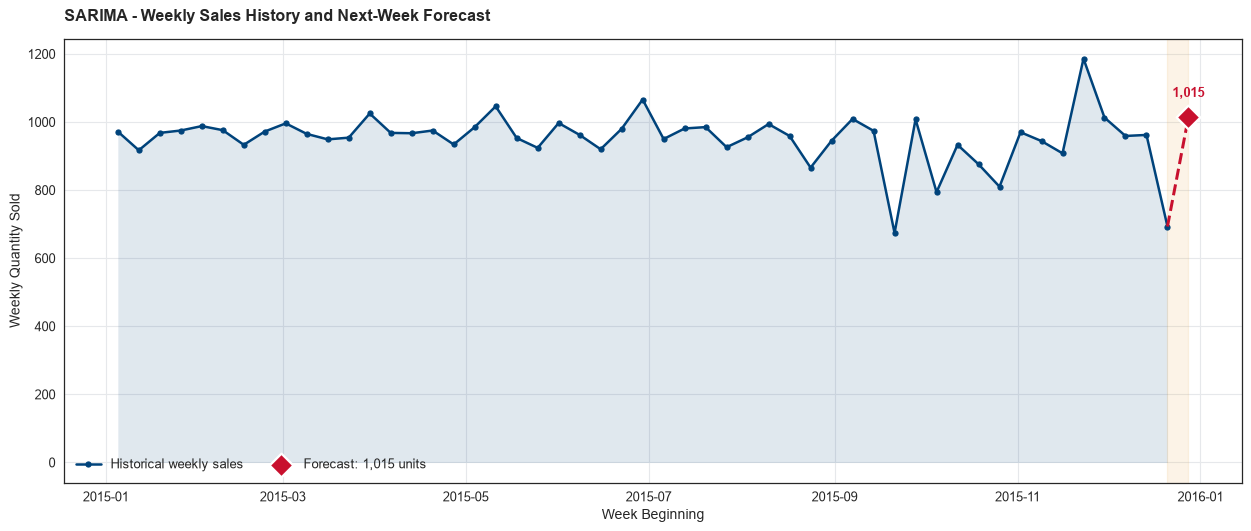

Total forecast for week beginning 2015-12-28: 1015 pizzas


In [57]:
if final_model is not None:
    total_next_week = float(final_model.forecast(steps=1).iloc[0])

    next_week_start = pizza_sales_weekly.index.max() + pd.Timedelta(weeks=1)

    plt.figure(figsize=(14, 6))
    plt.fill_between(pizza_sales_weekly.index, pizza_sales_weekly.values,
                     color=NAVY, alpha=0.12, linewidth=0)
    plt.plot(pizza_sales_weekly.index, pizza_sales_weekly.values,
             color=NAVY, linewidth=2, marker="o", markersize=4,
             label="Historical weekly sales")
    plt.plot([pizza_sales_weekly.index.max(), next_week_start],
             [pizza_sales_weekly.iloc[-1], total_next_week],
             color=RED, linestyle="--", linewidth=2.4)
    plt.scatter([next_week_start], [total_next_week], s=180, color=RED,
                zorder=6, marker="D", edgecolor="white", linewidth=1.8,
                label=f"Forecast: {total_next_week:,.0f} units")
    plt.annotate(f"{total_next_week:,.0f}",
                 (next_week_start, total_next_week),
                 textcoords="offset points", xytext=(0, 16),
                 ha="center", fontweight="bold", color=RED)
    plt.axvspan(pizza_sales_weekly.index.max(), next_week_start,
                color=AMBER, alpha=0.12)
    plt.title(f"{best_model_name} - Weekly Sales History and Next-Week Forecast",
              loc="left")
    plt.xlabel("Week Beginning")
    plt.ylabel("Weekly Quantity Sold")
    plt.legend(loc="lower left", ncol=2)
    save_fig("20_next_week_forecast.png")
    plt.show()

    print(f"Total forecast for week beginning {next_week_start.date()}: "
          f"{total_next_week:.0f} pizzas")

## 11. Forecasting Sales per Pizza Type

The purchase order needs ingredient quantities, and ingredients are defined per
**`pizza_name_id`** - which encodes both the recipe *and* the size (`bbq_ckn_l` is a
*large* Barbecue Chicken). A large pizza uses more of every ingredient than a small one,
so forecasting at the `pizza_name_id` level rather than by pizza name is what makes the
gram totals correct.

One weekly series is built per pizza type and each is forecast one week ahead.

In [58]:
def prepare_weekly_sales_by_pizza(df):
    d = df.copy()
    d["week"] = d["order_date"].dt.to_period("W").apply(lambda r: r.start_time)
    weekly = d.groupby(["week", "pizza_name_id"])["quantity"].sum().reset_index()
    # Keep exactly the same complete weeks that were used for the total series
    weekly = weekly[weekly["week"].isin(pizza_sales_weekly.index)]
    return weekly


weekly_by_pizza = prepare_weekly_sales_by_pizza(Sales_dataset)

pizza_pivot = (
    weekly_by_pizza.pivot(index="week", columns="pizza_name_id", values="quantity")
    .reindex(pizza_sales_weekly.index)
    .fillna(0)
)

print("Weekly matrix:", pizza_pivot.shape, "(weeks x pizza types)")
pizza_pivot.iloc[:5, :6]

Weekly matrix: (51, 91) (weeks x pizza types)


pizza_name_id,bbq_ckn_l,bbq_ckn_m,bbq_ckn_s,big_meat_s,brie_carre_s,calabrese_l
week,,,,,,
2015-01-05,13.0,11.0,9.0,35.0,8.0,5.0
2015-01-12,25.0,20.0,9.0,29.0,5.0,8.0
2015-01-19,15.0,18.0,12.0,38.0,11.0,3.0
2015-01-26,29.0,21.0,3.0,36.0,11.0,9.0
2015-02-02,18.0,21.0,10.0,41.0,15.0,5.0


In [59]:
def forecast_one_series(series, model_name, horizon=1):
    """Forecast `horizon` weeks ahead for a single pizza type."""
    try:
        if model_name == "SARIMA":
            fit = SARIMAX(
                series, order=sarima_best_params[0], seasonal_order=sarima_best_params[1],
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)
        elif model_name == "ARIMA":
            fit = ARIMA(series, order=arima_best_params).fit()
        else:
            fit = ARIMA(series, order=(1, 1, 1)).fit()
        value = float(np.asarray(fit.forecast(steps=horizon))[-1])
        if not np.isfinite(value):
            raise ValueError("non-finite forecast")
        return value, "model"
    except Exception:
        # Fall back to the recent average if the series is too sparse to fit
        return float(series.tail(4).mean()), "fallback"


next_week_start = pizza_sales_weekly.index.max() + pd.Timedelta(weeks=1)
next_week_end = next_week_start + pd.Timedelta(days=6)

forecasts, methods = {}, {}
for pizza_type in pizza_pivot.columns:
    value, method = forecast_one_series(pizza_pivot[pizza_type], best_model_name)
    forecasts[pizza_type] = max(0, int(round(value)))
    methods[pizza_type] = method

n_fallback = sum(1 for m in methods.values() if m == "fallback")
print(f"Forecast {len(forecasts)} pizza types for {next_week_start.date()} "
      f"-> {next_week_end.date()}")
print(f"Fitted with {best_model_name}: {len(forecasts) - n_fallback} | "
      f"fell back to recent average: {n_fallback}")

Forecast 91 pizza types for 2015-12-28 -> 2016-01-03
Fitted with SARIMA: 91 | fell back to recent average: 0


In [60]:
forecast_df = (
    pd.DataFrame({"pizza_name_id": list(forecasts.keys()),
                  "predicted_quantity": list(forecasts.values())})
    .merge(
        Sales_dataset[["pizza_name_id", "pizza_name", "pizza_size", "pizza_category"]]
        .drop_duplicates("pizza_name_id"),
        on="pizza_name_id", how="left",
    )
    .sort_values("predicted_quantity", ascending=False)
    .reset_index(drop=True)
)

total_forecast_units = int(forecast_df["predicted_quantity"].sum())

forecast_df.to_csv(os.path.join(OUTPUTS, "next_week_sales_forecast.csv"), index=False)

print(f"Total forecast for the week: {total_forecast_units} pizzas\n")
print("Top 15 pizza types by forecast demand:")
print(forecast_df.head(15).to_string(index=False))

Total forecast for the week: 1085 pizzas

Top 15 pizza types by forecast demand:
pizza_name_id  predicted_quantity                   pizza_name pizza_size pizza_category
   big_meat_s                  53           The Big Meat Pizza          S        Classic
classic_dlx_m                  31     The Classic Deluxe Pizza          M        Classic
five_cheese_l                  28        The Five Cheese Pizza          L         Veggie
four_cheese_l                  26        The Four Cheese Pizza          L         Veggie
  pepperoni_l                  25          The Pepperoni Pizza          L        Classic
  ital_supr_m                  24    The Italian Supreme Pizza          M        Supreme
   cali_ckn_l                  23 The California Chicken Pizza          L        Chicken
 spicy_ital_l                  23      The Spicy Italian Pizza          L        Supreme
 southw_ckn_l                  22  The Southwest Chicken Pizza          L        Chicken
    bbq_ckn_l                

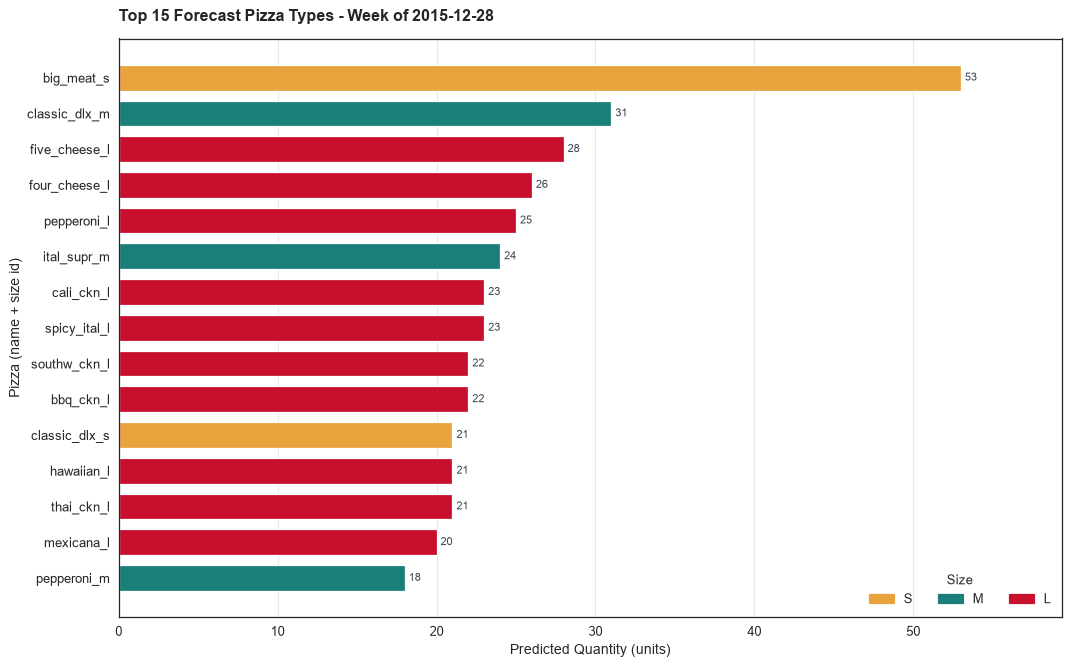

In [61]:
top_fc = forecast_df.head(15).iloc[::-1]
size_color = {"S": AMBER, "M": TEAL, "L": RED, "XL": NAVY, "XXL": PLUM}
fc_colors = [size_color.get(s, SLATE) for s in top_fc["pizza_size"]]

plt.figure(figsize=(12, 7.5))
plt.barh(top_fc["pizza_name_id"], top_fc["predicted_quantity"],
         color=fc_colors, height=0.72)
plt.title(f"Top 15 Forecast Pizza Types - Week of {next_week_start.date()}", loc="left")
plt.xlabel("Predicted Quantity (units)")
plt.ylabel("Pizza (name + size id)")
for i, v in enumerate(top_fc["predicted_quantity"]):
    plt.text(v + 0.25, i, str(v), va="center", fontsize=9, color=SLATE)
plt.xlim(0, top_fc["predicted_quantity"].max() * 1.12)
plt.gca().yaxis.grid(False)
present = [s for s in ["S", "M", "L", "XL", "XXL"] if s in set(top_fc["pizza_size"])]
plt.legend([plt.Rectangle((0, 0), 1, 1, color=size_color[s]) for s in present],
           present, title="Size", loc="lower right", ncol=len(present))
save_fig("21_next_week_pizza_forecast.png")
plt.show()

## 12. Purchase Order Generation

The final deliverable. For every ingredient:

```
required grams  =  SUM over pizza types (  grams per pizza  x  forecast units  )
```

The ingredient table is joined to the forecast on `pizza_name_id`, so each pizza's
size-specific grammage is multiplied by that exact size's predicted demand.

In [62]:
ingredients_predicted = Ingredients_dataset.copy()
ingredients_predicted["predicted_quantity"] = ingredients_predicted["pizza_name_id"].map(
    forecasts
)

unmatched = ingredients_predicted["predicted_quantity"].isna().sum()
print(f"Ingredient rows with no matching forecast: {unmatched}")
ingredients_predicted["predicted_quantity"] = ingredients_predicted[
    "predicted_quantity"
].fillna(0)

ingredients_predicted["total_ingredient_qty"] = (
    ingredients_predicted["Items_Qty_In_Grams"] * ingredients_predicted["predicted_quantity"]
)

ingredients_predicted.head(10)

Ingredient rows with no matching forecast: 0


,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams,predicted_quantity,total_ingredient_qty
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0,22,880.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0,22,330.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0,22,440.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0,22,660.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0,22,1320.0
5,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecue Sauce,15.0,22,330.0
6,bbq_ckn_m,The Barbecue Chicken Pizza,Barbecued Chicken,30.0,16,480.0
7,bbq_ckn_m,The Barbecue Chicken Pizza,Red Peppers,10.0,16,160.0
8,bbq_ckn_m,The Barbecue Chicken Pizza,Green Peppers,15.0,16,240.0
9,bbq_ckn_m,The Barbecue Chicken Pizza,Tomatoes,20.0,16,320.0


In [63]:
purchase_order = (
    ingredients_predicted.groupby("pizza_ingredients")["total_ingredient_qty"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
purchase_order.columns = ["Ingredient", "Required_Quantity_Grams"]
purchase_order["Required_Quantity_Kg"] = (
    purchase_order["Required_Quantity_Grams"] / 1000
).round(2)
purchase_order.insert(0, "Item_No", range(1, len(purchase_order) + 1))

purchase_order.to_csv(os.path.join(OUTPUTS, "purchase_order_next_week.csv"), index=False)
purchase_order.to_csv(os.path.join(OUTPUTS, "predicted_ingredient_totals.csv"), index=False)

print(f"PURCHASE ORDER - week of {next_week_start.date()} to {next_week_end.date()}")
print(f"Based on a forecast of {total_forecast_units} pizzas "
      f"({best_model_name}, MAPE {best_model_mape:.4f})")
print(f"{len(purchase_order)} distinct ingredients | "
      f"{purchase_order['Required_Quantity_Kg'].sum():,.1f} kg total\n")
print(purchase_order.to_string(index=False))

PURCHASE ORDER - week of 2015-12-28 to 2016-01-03
Based on a forecast of 1085 pizzas (SARIMA, MAPE 0.0804)
64 distinct ingredients | 198.8 kg total

 Item_No                 Ingredient  Required_Quantity_Grams  Required_Quantity_Kg
       1                    Chicken                  19200.0                 19.20
       2                 Red Onions                  19000.0                 19.00
       3                  Capocollo                  15950.0                 15.95
       4                      Bacon                  13300.0                 13.30
       5                   Tomatoes                  12560.0                 12.56
       6                  Pepperoni                  10770.0                 10.77
       7                  Mushrooms                   8660.0                  8.66
       8                    Spinach                   6735.0                  6.74
       9                     Garlic                   6615.0                  6.62
      10             

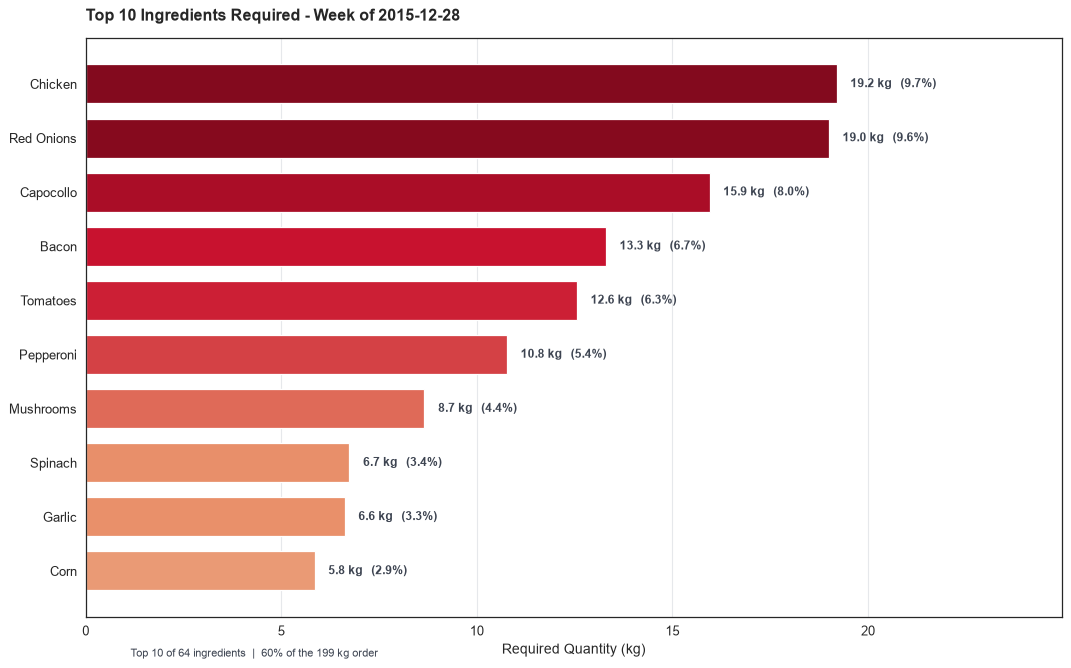

In [64]:
top_ing = purchase_order.head(10).iloc[::-1]
share = top_ing["Required_Quantity_Kg"] / purchase_order["Required_Quantity_Kg"].sum() * 100

plt.figure(figsize=(12, 7.5))
plt.barh(top_ing["Ingredient"], top_ing["Required_Quantity_Kg"],
         color=shade(top_ing["Required_Quantity_Kg"]), height=0.72)
plt.title(f"Top 10 Ingredients Required - Week of {next_week_start.date()}", loc="left")
plt.xlabel("Required Quantity (kg)")
for i, (v, pc) in enumerate(zip(top_ing["Required_Quantity_Kg"], share)):
    plt.text(v + 0.35, i, f"{v:,.1f} kg   ({pc:.1f}%)", va="center",
             fontsize=9.5, fontweight="bold", color=SLATE)
plt.xlim(0, top_ing["Required_Quantity_Kg"].max() * 1.30)
plt.gca().yaxis.grid(False)
plt.figtext(0.125, 0.02,
            f"Top 10 of {len(purchase_order)} ingredients  |  "
            f"{share.sum():.0f}% of the {purchase_order['Required_Quantity_Kg'].sum():,.0f} kg order",
            fontsize=9, color=SLATE)
save_fig("22_top_10_ingredients.png")
plt.show()

### Purchase order summary

In [65]:
summary = pd.DataFrame({
    "Metric": [
        "Forecast week start",
        "Forecast week end",
        "Model used",
        "Model MAPE",
        "Model accuracy (1 - MAPE)",
        "Total pizzas forecast",
        "Distinct pizza types forecast",
        "Distinct ingredients to order",
        "Total ingredient weight (kg)",
        "Heaviest single ingredient",
    ],
    "Value": [
        str(next_week_start.date()),
        str(next_week_end.date()),
        best_model_name,
        f"{best_model_mape:.4f}",
        f"{1 - best_model_mape:.2%}",
        f"{total_forecast_units:,}",
        str(len(forecast_df)),
        str(len(purchase_order)),
        f"{purchase_order['Required_Quantity_Kg'].sum():,.2f}",
        f"{purchase_order.iloc[0]['Ingredient']} "
        f"({purchase_order.iloc[0]['Required_Quantity_Kg']:,.1f} kg)",
    ],
})

summary.to_csv(os.path.join(OUTPUTS, "purchase_order_summary.csv"), index=False)
summary

,Metric,Value
0,Forecast week start,2015-12-28
1,Forecast week end,2016-01-03
2,Model used,SARIMA
3,Model MAPE,0.0804
4,Model accuracy (1 - MAPE),91.96%
5,Total pizzas forecast,"1,085"
6,Distinct pizza types forecast,91
7,Distinct ingredients to order,64
8,Total ingredient weight (kg),198.79
9,Heaviest single ingredient,Chicken (19.2 kg)


## 13. Conclusion

**What was built.** A complete pipeline that takes a year of raw Domino's transaction data
and produces a costed, actionable ingredient purchase order for the coming week.

**Data.** Both source files arrived with missing values. Rather than dropping the affected
rows, every gap was reconstructed from the relationships already present in the data -
`total_price` recomputed arithmetically, categories and names recovered by lookup, and
`pizza_name_id` rebuilt from the `(name, size)` pair. No sales record was lost, so the
demand signal stays intact.

**Modelling.** Five approaches were trained on identical weekly data and scored with MAPE
on the same held-out weeks. The comparison table above records the result.

**Purchase order.** The winning model was refitted on the full year, then applied to each
pizza type separately so that size-specific ingredient grammage is respected. Multiplying
through the recipe table gives the final order.

**Business value.** The order translates a statistical forecast into a concrete
procurement decision - how many kilograms of each ingredient to buy - which is what
actually reduces both waste and stockouts.

**Honest limitations.**

- Only one year of data exists, so annual seasonality cannot be learned, only weekly and
  monthly variation.
- Model selection used the held-out weeks to choose hyperparameters, so the reported MAPE
  is mildly optimistic as an estimate of true future error.
- The purchase order assumes zero opening stock, no wastage allowance and no supplier
  pack sizes. A production system would layer those on top.

In [66]:
print("=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)
for label, path in [
    ("Cleaned sales", os.path.join(PROCESSED, "cleaned_pizza_sales.csv")),
    ("Cleaned ingredients", os.path.join(PROCESSED, "cleaned_pizza_ingredients.csv")),
    ("Model comparison", os.path.join(OUTPUTS, "model_comparison.csv")),
    ("Sales forecast", os.path.join(OUTPUTS, "next_week_sales_forecast.csv")),
    ("Purchase order", os.path.join(OUTPUTS, "purchase_order_next_week.csv")),
    ("Saved model", model_path),
]:
    print(f"  {label:22s} -> {'OK' if os.path.exists(path) else 'MISSING'}")
print(f"  {'Figures':22s} -> {len(os.listdir(FIGURES))} PNGs")
print("=" * 70)

PIPELINE COMPLETE
  Cleaned sales          -> OK
  Cleaned ingredients    -> OK
  Model comparison       -> OK
  Sales forecast         -> OK
  Purchase order         -> OK
  Saved model            -> OK
  Figures                -> 22 PNGs
